Iniciando lectura de archivos...
Lectura completada. Total de registros cargados: 300


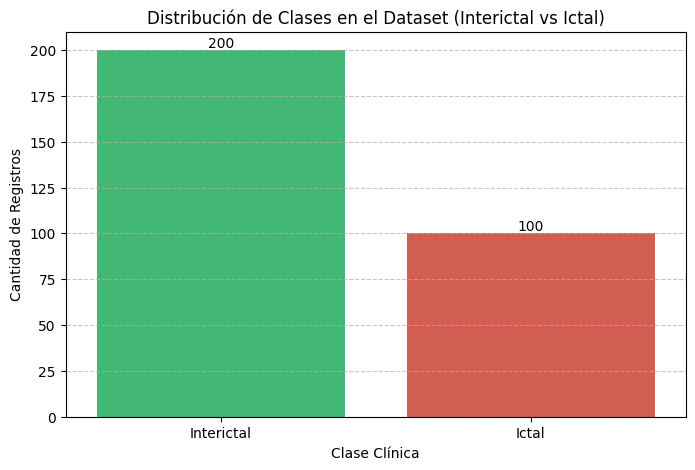

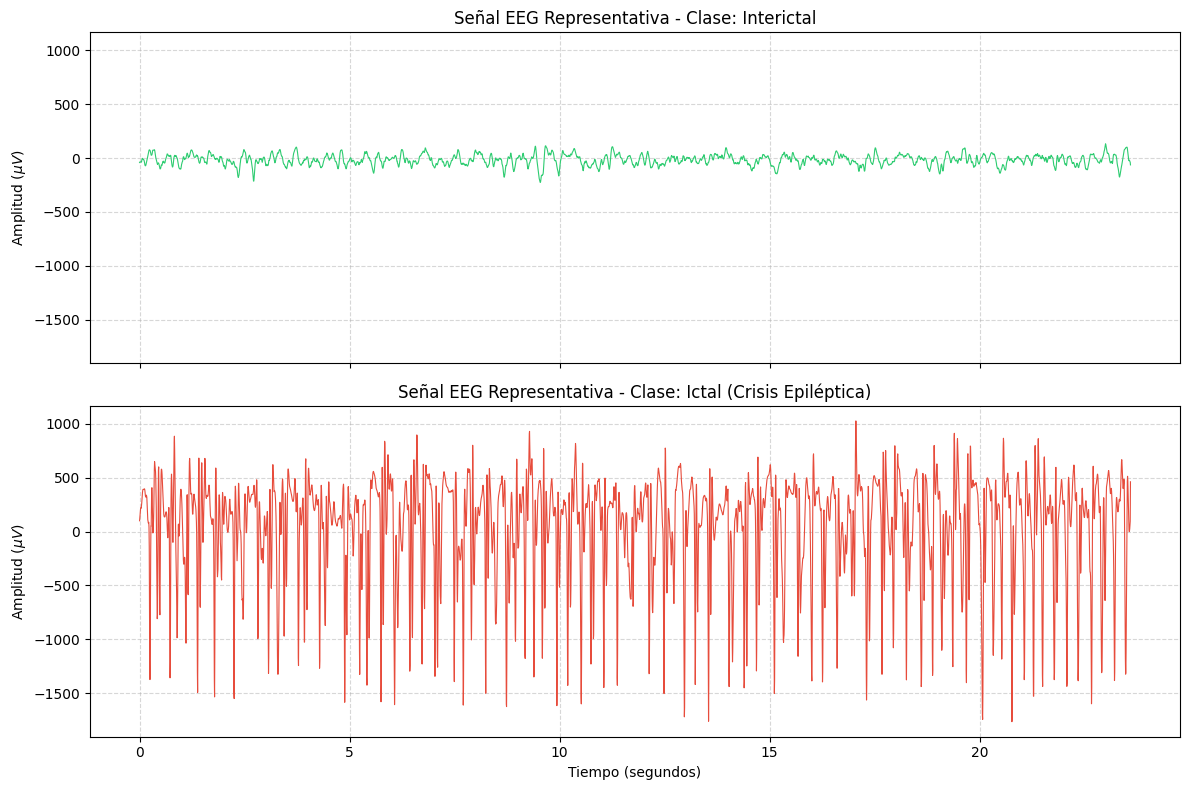


Generando tabla resumen de parámetros estadísticos...

Tabla Resumen de Parámetros Estadísticos (Media ± Desviación Estándar):


,Media,Desv_Estandar,Max_Amplitud,Varianza,Asimetria,Curtosis
Clase,,,,,,
Ictal,-4.75 ± 27.16,306.57 ± 147.96,910.05 ± 440.93,115659.63 ± 100933.88,-0.06 ± 0.76,0.43 ± 1.19
Interictal,-7.54 ± 23.8,58.22 ± 43.62,212.22 ± 213.47,5282.71 ± 15898.16,-0.04 ± 0.58,0.98 ± 1.91


In [ ]:
# =====================================================================
# CELDA 1 — CARGA DE DATOS DESDE DRIVE Y ESTADÍSTICAS BÁSICAS
# =====================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from google.colab import drive

drive.mount('/content/drive')


# 2. Definición de rutas y parámetros
# Ajuste de ruta según el directorio proporcionado
base_path = '/content/drive/MyDrive/Proyecto_RecPatrones/Dataset-BONN'

# Mapeo de carpetas: Ictal vs Interictal (Se excluyen grupos A y B)
# N (C), F (D) -> Interictal
# S (E) -> Ictal
folder_mapping = {
    'N': 'Interictal',
    'F': 'Interictal',
    'S': 'Ictal'
}

# Parámetros fisiológicos
fs = 173.61 # Frecuencia de muestreo en Hz
n_samples = 4097 # Muestras por segmento

# 3. Carga de datos
data_signals = []
labels = []
data_stats = [] # Lista unificada para guardar estadísticas por cada señal

print("Iniciando lectura de archivos...")
for folder, label in folder_mapping.items():
    folder_path = os.path.join(base_path, folder)

    if os.path.exists(folder_path):
        files = sorted(os.listdir(folder_path))
        for filename in files:
            file_path = os.path.join(folder_path, filename)
            try:
                # Lectura de la señal
                signal = np.loadtxt(file_path)
                data_signals.append(signal)
                labels.append(label)

                # Cálculo inmediato de métricas estadísticas
                stats = {
                    'Clase': label,
                    'Media': np.mean(signal),
                    'Desv_Estandar': np.std(signal),
                    'Max_Amplitud': np.max(signal),
                    'Varianza': np.var(signal),
                    'Asimetria': skew(signal),
                    'Curtosis': kurtosis(signal)
                }
                data_stats.append(stats)

            except Exception as e:
                print(f"Error al leer el archivo {file_path}: {e}")
    else:
        print(f"Advertencia: No se encontró la ruta {folder_path}")

print(f"Lectura completada. Total de registros cargados: {len(labels)}")

# 4. Distribución de Clases
df_labels = pd.DataFrame({'Clase': labels})

plt.figure(figsize=(8, 5))
# Colores actualizados para diferenciar claramente las dos clases
ax = sns.countplot(data=df_labels, x='Clase', hue='Clase', palette=['#2ecc71', '#e74c3c'], order=['Interictal', 'Ictal'], legend=False)
plt.title('Distribución de Clases en el Dataset (Interictal vs Ictal)')
plt.xlabel('Clase Clínica')
plt.ylabel('Cantidad de Registros')

# Añadir etiquetas de cantidad sobre las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Visualización de Muestras Representativas
# Vector de tiempo (23.6 segundos)
time_vector = np.arange(n_samples) / fs

# Identificar el índice del primer registro de cada clase
idx_interictal = labels.index('Interictal')
idx_ictal = labels.index('Ictal')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

# Gráfica señal Interictal
axes[0].plot(time_vector, data_signals[idx_interictal], color='#2ecc71', linewidth=0.8)
axes[0].set_title('Señal EEG Representativa - Clase: Interictal')
axes[0].set_ylabel(r'Amplitud ($\mu V$)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Gráfica señal Ictal
axes[1].plot(time_vector, data_signals[idx_ictal], color='#e74c3c', linewidth=0.8)
axes[1].set_title('Señal EEG Representativa - Clase: Ictal (Crisis Epiléptica)')
axes[1].set_xlabel('Tiempo (segundos)')
axes[1].set_ylabel(r'Amplitud ($\mu V$)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 6. Tabla Resumen de Parámetros Estadísticos
print("\nGenerando tabla resumen de parámetros estadísticos...")
df_detailed = pd.DataFrame(data_stats)

# Agrupación para obtener la media y desviación estándar de cada métrica por clase
agg_funcs = {
    'Media': ['mean', 'std'],
    'Desv_Estandar': ['mean', 'std'],
    'Max_Amplitud': ['mean', 'std'],
    'Varianza': ['mean', 'std'],
    'Asimetria': ['mean', 'std'],
    'Curtosis': ['mean', 'std']
}

summary_table = df_detailed.groupby('Clase').agg(agg_funcs).round(2)

# Formateo de la tabla de salida para visualizar "Media ± Desviación Estándar"
formatted_table = pd.DataFrame()
for col in agg_funcs.keys():
    formatted_table[col] = summary_table[col]['mean'].astype(str) + " ± " + summary_table[col]['std'].astype(str)

print("\nTabla Resumen de Parámetros Estadísticos (Media ± Desviación Estándar):")
display(formatted_table)


--- INICIANDO FASES DE MACHINE LEARNING ---

Generando gráficas de comprobación metodológica...


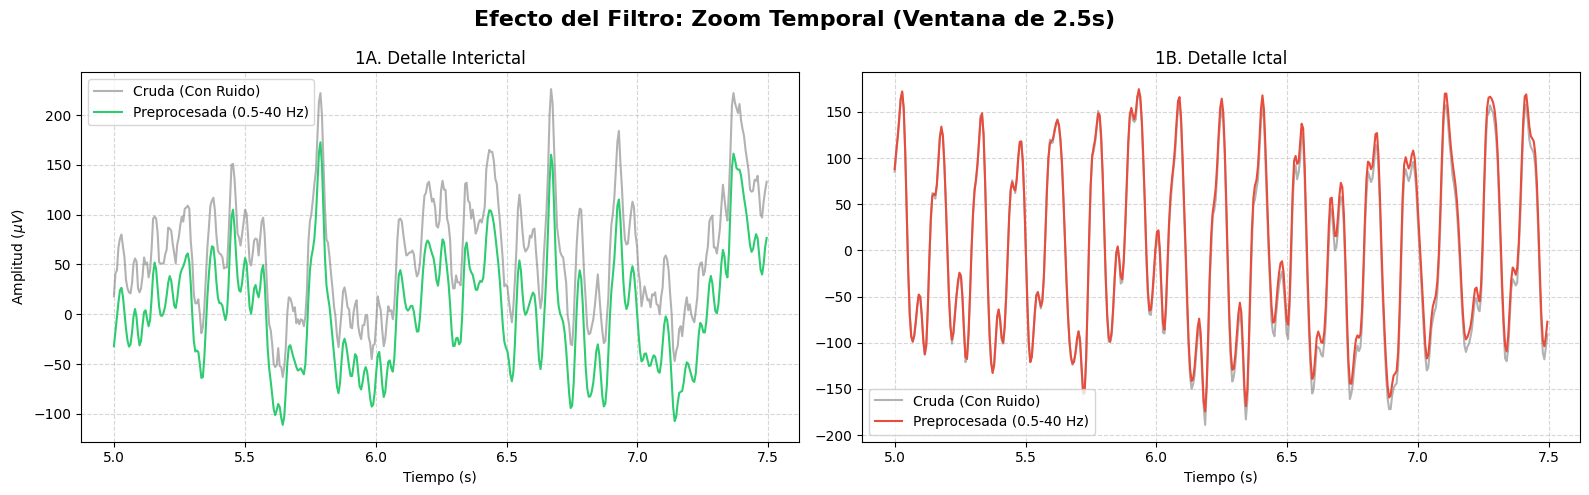

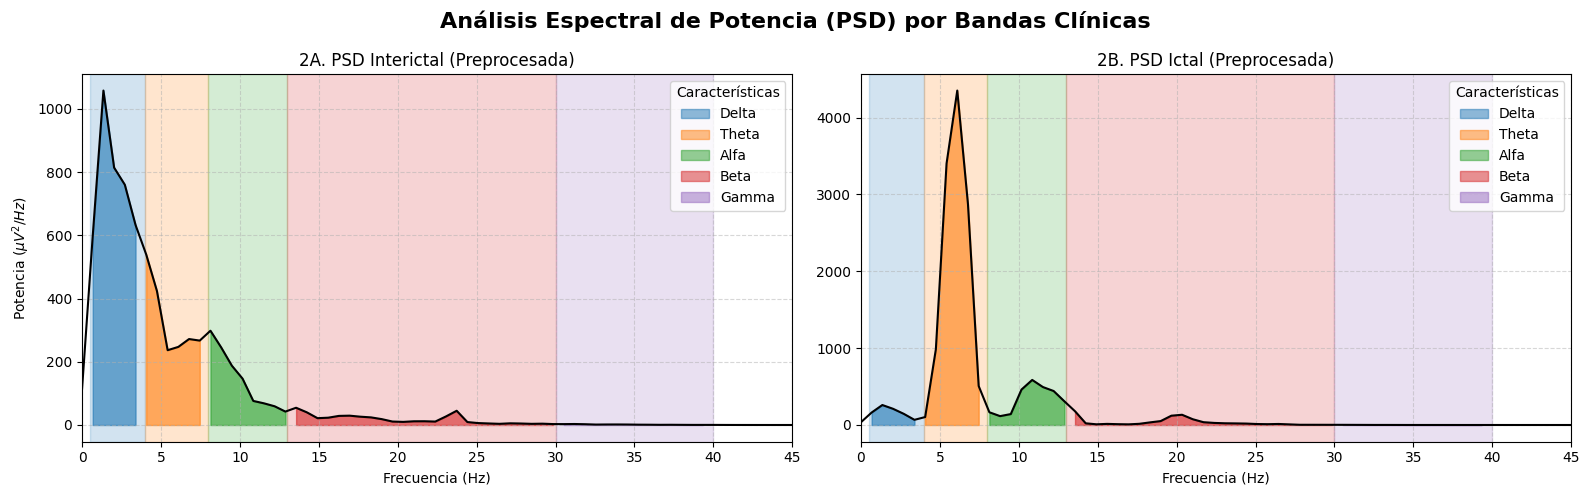


Extrayendo características para todo el dataset...

Proceso de preparación finalizado. Variables listas para los experimentos.


In [ ]:
# =====================================================================
# CELDA 2 — PREPARACIÓN: SPLIT, FUNCIONES Y CONSTANTES
#           (Todo lo necesario para que los experimentos funcionen)
# =====================================================================

from scipy.signal import butter, filtfilt, welch
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n--- INICIANDO FASES DE MACHINE LEARNING ---")

# ---------------------------------------------------------
# TRANSICIÓN: Adaptación de tus datos ya cargados
# ---------------------------------------------------------
X_raw = np.array(data_signals)
y_num = np.array([0 if label == 'Interictal' else 1 for label in labels])

# ---------------------------------------------------------
# FASE 2: DIVISIÓN DE DATOS (70% Train, 15% Val, 15% Test)
# ---------------------------------------------------------
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y_num, test_size=0.15, stratify=y_num, random_state=42
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42
)

# ---------------------------------------------------------
# FUNCIONES DE PREPROCESAMIENTO Y EXTRACCIÓN
# ---------------------------------------------------------
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alfa': (8, 13), 'Beta': (13, 30), 'Gamma': (30, 40)}
band_colors = {'Delta': '#1f77b4', 'Theta': '#ff7f0e', 'Alfa': '#2ca02c', 'Beta': '#d62728', 'Gamma': '#9467bd'}

# ---------------------------------------------------------
# VISUALIZACIÓN CLÍNICA: Zoom Temporal y PSD por Bandas
# ---------------------------------------------------------
print("\nGenerando gráficas de comprobación metodológica...")

idx_interictal = np.where(y_train == 0)[0][0]
idx_ictal = np.where(y_train == 1)[0][0]

sig_raw_int = X_train_raw[idx_interictal]
sig_filt_int = butter_bandpass_filter(sig_raw_int, 0.5, 40.0, fs)

sig_raw_ict = X_train_raw[idx_ictal]
sig_filt_ict = butter_bandpass_filter(sig_raw_ict, 0.5, 40.0, fs)

time_vector = np.arange(X_train_raw.shape[1]) / fs

# --- GRÁFICA 1: ZOOM TEMPORAL (Superposición en ventana de 2.5 seg) ---
start_idx = int(5.0 * fs)
end_idx = int(7.5 * fs)

fig1, axes1 = plt.subplots(1, 2, figsize=(16, 5))
fig1.suptitle('Efecto del Filtro: Zoom Temporal (Ventana de 2.5s)', fontsize=16, fontweight='bold')

# Zoom Interictal
axes1[0].plot(time_vector[start_idx:end_idx], sig_raw_int[start_idx:end_idx], color='gray', label='Cruda (Con Ruido)', linewidth=1.5, alpha=0.6)
axes1[0].plot(time_vector[start_idx:end_idx], sig_filt_int[start_idx:end_idx], color='#2ecc71', label='Preprocesada (0.5-40 Hz)', linewidth=1.5)
axes1[0].set_title('1A. Detalle Interictal')
axes1[0].set_xlabel('Tiempo (s)')
axes1[0].set_ylabel(r'Amplitud ($\mu V$)')
axes1[0].legend()
axes1[0].grid(True, linestyle='--', alpha=0.5)

# Zoom Ictal
axes1[1].plot(time_vector[start_idx:end_idx], sig_raw_ict[start_idx:end_idx], color='gray', label='Cruda (Con Ruido)', linewidth=1.5, alpha=0.6)
axes1[1].plot(time_vector[start_idx:end_idx], sig_filt_ict[start_idx:end_idx], color='#e74c3c', label='Preprocesada (0.5-40 Hz)', linewidth=1.5)
axes1[1].set_title('1B. Detalle Ictal')
axes1[1].set_xlabel('Tiempo (s)')
axes1[1].legend()
axes1[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- GRÁFICA 2: ESPECTRO DE POTENCIA (PSD COLOREADO) ---
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle('Análisis Espectral de Potencia (PSD) por Bandas Clínicas', fontsize=16, fontweight='bold')

signals_for_psd = [
    ('2A. PSD Interictal (Preprocesada)', sig_filt_int),
    ('2B. PSD Ictal (Preprocesada)', sig_filt_ict)
]

for i, (title, sig_filt) in enumerate(signals_for_psd):
    ax_freq = axes2[i]
    freqs, psd = welch(sig_filt, fs=fs, nperseg=256)

    idx_plot = freqs <= 50
    ax_freq.plot(freqs[idx_plot], psd[idx_plot], color='black', linewidth=1.5)

    patches = []
    for band_name, (f_min, f_max) in bands.items():
        color = band_colors[band_name]
        ax_freq.axvspan(f_min, f_max, color=color, alpha=0.2)
        patches.append(mpatches.Patch(color=color, alpha=0.5, label=band_name))

        idx_band = np.logical_and(freqs >= f_min, freqs <= f_max)
        ax_freq.fill_between(freqs[idx_band], psd[idx_band], color=color, alpha=0.6)

    ax_freq.set_title(title)
    ax_freq.set_xlabel('Frecuencia (Hz)')
    if i == 0:
        ax_freq.set_ylabel(r'Potencia ($\mu V^2/Hz$)')
    ax_freq.set_xlim(0, 45)
    ax_freq.legend(handles=patches, loc='upper right', title='Características')
    ax_freq.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# FASE 3 y 4: EXTRACCIÓN MASIVA DE CARACTERÍSTICAS
# ---------------------------------------------------------
def extract_features(signal, fs):
    sig_filtered = butter_bandpass_filter(signal, 0.5, 40.0, fs)
    var = np.var(sig_filtered)
    skw = skew(sig_filtered)
    kurt = kurtosis(sig_filtered)
    line_length = np.sum(np.abs(np.diff(sig_filtered)))
    freqs, psd = welch(sig_filtered, fs=fs, nperseg=256)
    features = [var, skw, kurt, line_length]
    for f_min, f_max in bands.values():
        idx = np.logical_and(freqs >= f_min, freqs <= f_max)
        features.append(np.sum(psd[idx]))
    return features

feature_names = ['Varianza', 'Asimetria', 'Curtosis', 'Line_Length',
                 'P_Delta', 'P_Theta', 'P_Alfa', 'P_Beta', 'P_Gamma']

print("\nExtrayendo características para todo el dataset...")
X_train_feat = np.array([extract_features(sig, fs) for sig in X_train_raw])
X_val_feat   = np.array([extract_features(sig, fs) for sig in X_val_raw])
X_test_feat  = np.array([extract_features(sig, fs) for sig in X_test_raw])

print("\nProceso de preparación finalizado. Variables listas para los experimentos.")


Relevancia de características (ANOVA F-value):


,Característica,F-Score
3,Line_Length,343.026185
0,Varianza,158.288076
6,P_Alfa,127.830108
5,P_Theta,114.745969
8,P_Gamma,84.008562
7,P_Beta,65.340985
4,P_Delta,37.240174
2,Curtosis,8.704559
1,Asimetria,0.014732



Proceso finalizado. Dimensionalidad final: 6 características por registro.

--- GENERANDO VISUALIZACIONES DE SEPARABILIDAD DE CLASES ---


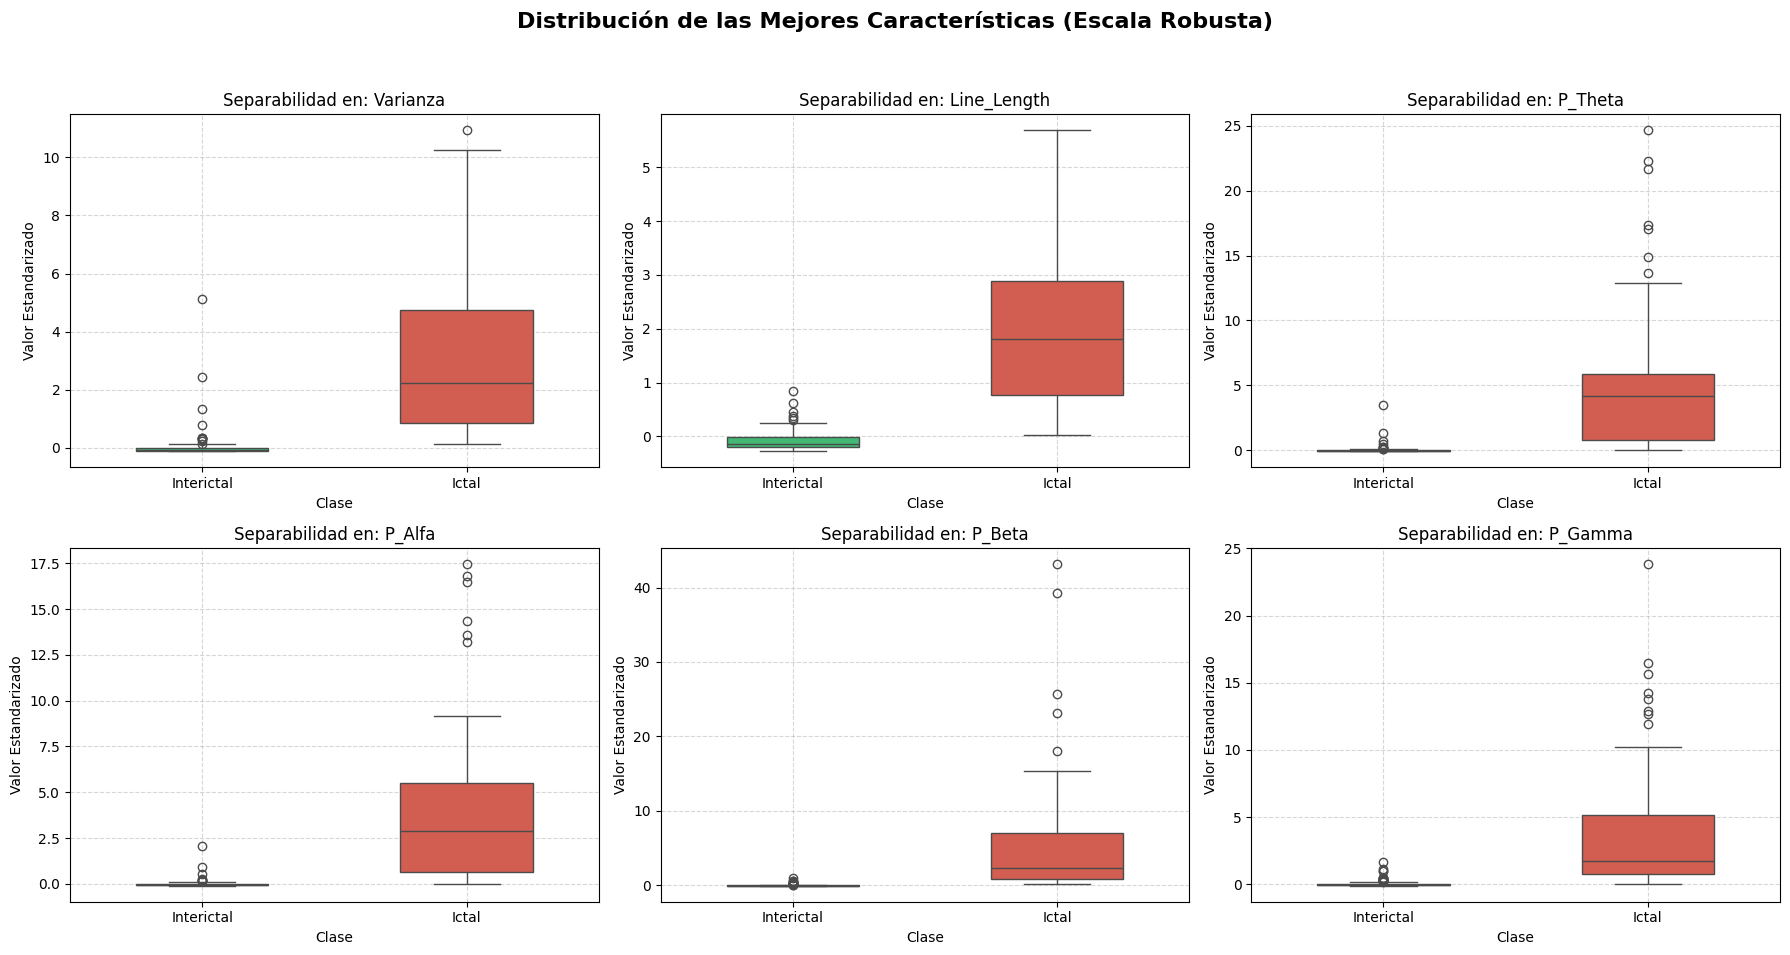

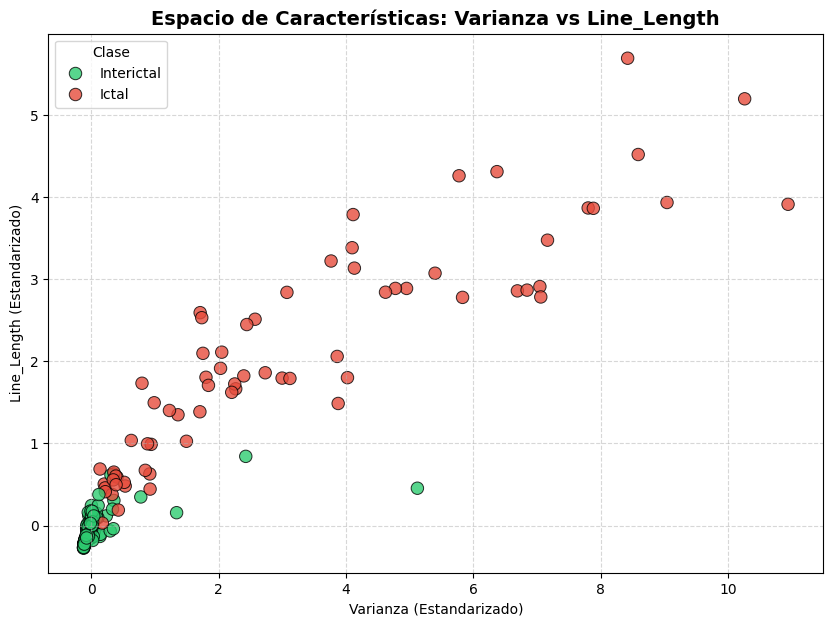

In [ ]:
# =====================================================================
# CELDA 3 — EXPERIMENTO 0 (PRIMER BORRADOR)
#           Selección arbitraria de k=6 características y visualización
#           de la separabilidad de clases de esas 6 características.
#           (Requiere ejecutar antes las celdas 1 y 2: usa X_train_feat,
#            X_val_feat, X_test_feat, feature_names y los imports de sklearn.)
# =====================================================================

import seaborn as sns

# ---------------------------------------------------------
# FASE 5: ESTANDARIZACIÓN Y SELECCIÓN DE CARACTERÍSTICAS
# ---------------------------------------------------------
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_feat)
X_val_scaled = scaler.transform(X_val_feat)
X_test_scaled = scaler.transform(X_test_feat)

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, y_train)

df_scores = pd.DataFrame({
    'Característica': feature_names,
    'F-Score': selector.scores_
}).sort_values(by='F-Score', ascending=False)

print("\nRelevancia de características (ANOVA F-value):")
display(df_scores)

# Reducción a las 6 mejores características
k_best = 6
selector_final = SelectKBest(score_func=f_classif, k=k_best)
X_train_final = selector_final.fit_transform(X_train_scaled, y_train)
X_val_final   = selector_final.transform(X_val_scaled)
X_test_final  = selector_final.transform(X_test_scaled)

print(f"\nProceso finalizado. Dimensionalidad final: {X_train_final.shape[1]} características por registro.")

print("\n--- GENERANDO VISUALIZACIONES DE SEPARABILIDAD DE CLASES ---")

# 1. Recuperar los índices y nombres en el orden original correcto
indices_seleccionados = selector_final.get_support(indices=True)
nombres_seleccionados = [feature_names[i] for i in indices_seleccionados]

# 2. Crear el DataFrame (Ahora sí coinciden columnas y datos)
df_train_final = pd.DataFrame(X_train_final, columns=nombres_seleccionados)
df_train_final['Clase'] = ['Ictal' if label == 1 else 'Interictal' for label in y_train]

# --- GRÁFICA 1: BOXPLOTS (Distribución Individual) ---
# Demuestra si la mediana y los rangos intercuartílicos de cada característica se separan por clase
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribución de las Mejores Características (Escala Robusta)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for i, feature in enumerate(nombres_seleccionados):
    # CORRECCIÓN: Se añadió hue='Clase' y legend=False para evitar el FutureWarning
    sns.boxplot(x='Clase', y=feature, hue='Clase', data=df_train_final,
                palette={'Interictal': '#2ecc71', 'Ictal': '#e74c3c'}, ax=axes[i], width=0.5, legend=False)
    axes[i].set_title(f'Separabilidad en: {feature}')
    axes[i].set_ylabel('Valor Estandarizado')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- GRÁFICA 2: SCATTER PLOT (Separación Bidimensional) ---
# Demuestra visualmente cómo interactúan los 2 mejores predictores juntos
top_1 = nombres_seleccionados[0] # Line Length
top_2 = nombres_seleccionados[1] # Varianza

plt.figure(figsize=(10, 7))
sns.scatterplot(x=top_1, y=top_2, hue='Clase', data=df_train_final,
                palette={'Interictal': '#2ecc71', 'Ictal': '#e74c3c'},
                s=80, alpha=0.8, edgecolor='k')

plt.title(f'Espacio de Características: {top_1} vs {top_2}', fontsize=14, fontweight='bold')
plt.xlabel(f'{top_1} (Estandarizado)')
plt.ylabel(f'{top_2} (Estandarizado)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- INICIANDO OPTIMIZACIÓN DEL PIPELINE (FEEDBACK) ---

[1/4] Aplicando enventanado (Epoching) de 2 segundos...
 -> Registros originales (Train): 209
 -> Nuevos registros (Train Epoched): 2299

[2/4] Extrayendo características de las nuevas ventanas...

[3/4] Generando Mapa de Correlación de características...


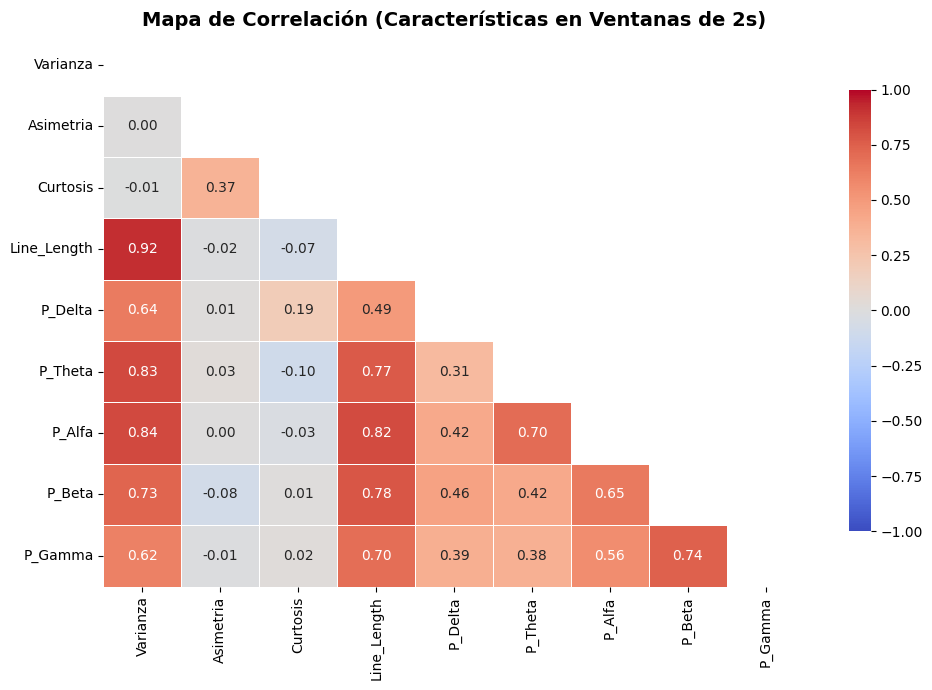


[4/4] Evaluando el número óptimo de características (k)...


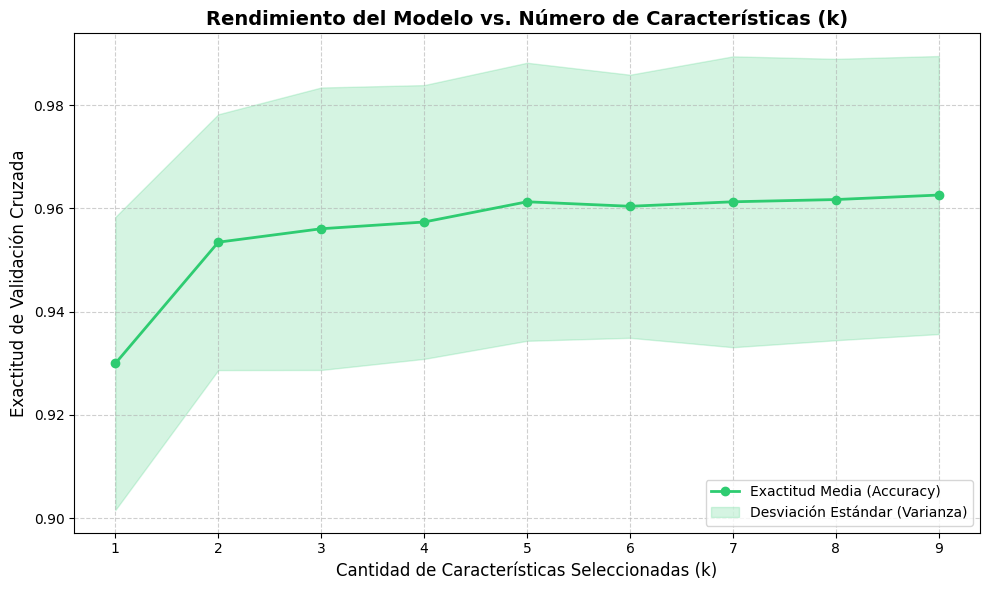


✅ El 'k' que maximiza el rendimiento es k=9 (Exactitud media: 96.26%).
Nota: Si el rendimiento se estanca antes, conviene elegir el 'k' menor (modelo más simple).
--- RANKING DEFINITIVO (Datos enventanados y sin Varianza) ---


,Característica,F-Score_Nuevo
2,Line_Length,3568.975888
5,P_Alfa,1052.652210
4,P_Theta,1049.406639
7,P_Gamma,635.268805
6,P_Beta,617.341887
3,P_Delta,387.532346
1,Curtosis,24.852377
0,Asimetria,0.039968



Las 7 características seleccionadas son:
- Curtosis
- Line_Length
- P_Delta
- P_Theta
- P_Alfa
- P_Beta
- P_Gamma

   FASE 6 MEJORADA: RF OPTIMIZADO + XGBOOST + SMOTE + UMBRAL (k=7)

[0/7] Preparando conjuntos Val y Test (enventanado + features)...
[1/7] Seleccionando k=7 características...
  Dimensiones finales de entrenamiento: (2299, 7)
  Dimensiones finales de validación:    (506, 7)
  Características seleccionadas (k=7): ['Curtosis', 'Line_Length', 'P_Delta', 'P_Theta', 'P_Alfa', 'P_Beta', 'P_Gamma']

[2/7] Evaluando desbalance de clases y aplicando SMOTE...
  Antes de SMOTE -> Interictal (0): 1529 | Ictal (1): 770
  Ratio de desbalance: 1.99:1
  Después de SMOTE -> Interictal: 1529 | Ictal: 1529 (balanceado)

[3/7] Entrenando modelos...
  [A] Baseline (Regresión Logística con class_weight='balanced')...
  [B] Random Forest — RandomizedSearchCV (20 combinaciones, CV=5)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
      Mejores hiperparámetros RF: {'n_estimator

,Métrica,Baseline (Reg. Logística),RF Optimizado,XGBoost Optimizado
0,Accuracy,0.9901,0.9960,0.9842
1,Precision,1.0000,1.0000,0.9816
2,Sensibilidad (Recall),0.9697,0.9879,0.9697
3,Especificidad,1.0000,1.0000,0.9912
4,F1-Score,0.9846,0.9939,0.9756
5,AUC-ROC,1.0000,0.9999,0.9992
6,Falsos Negativos,5.0000,2.0000,5.0000
7,Falsos Positivos,0.0000,0.0000,3.0000



>> Random Forest obtiene el mejor F1 y menos Falsos Negativos en validación.
>> Se elige RANDOM FOREST como modelo definitivo para la evaluación en TEST.

[5/7] Generando visualizaciones...


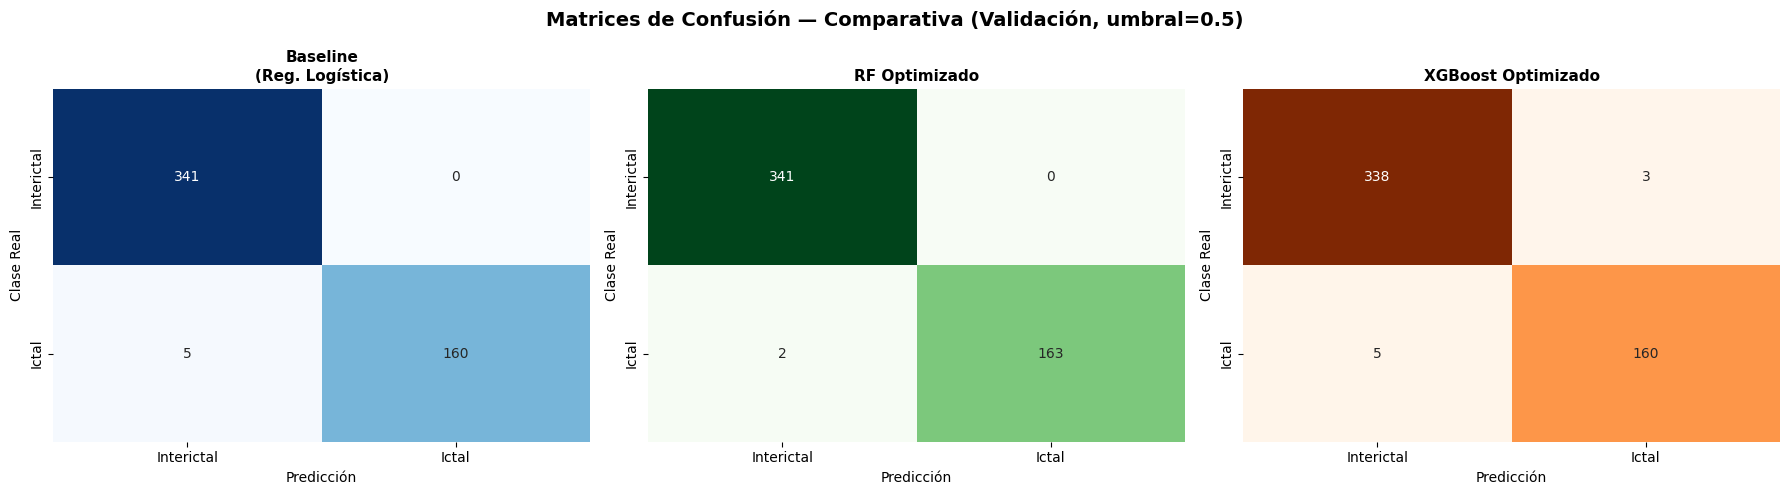

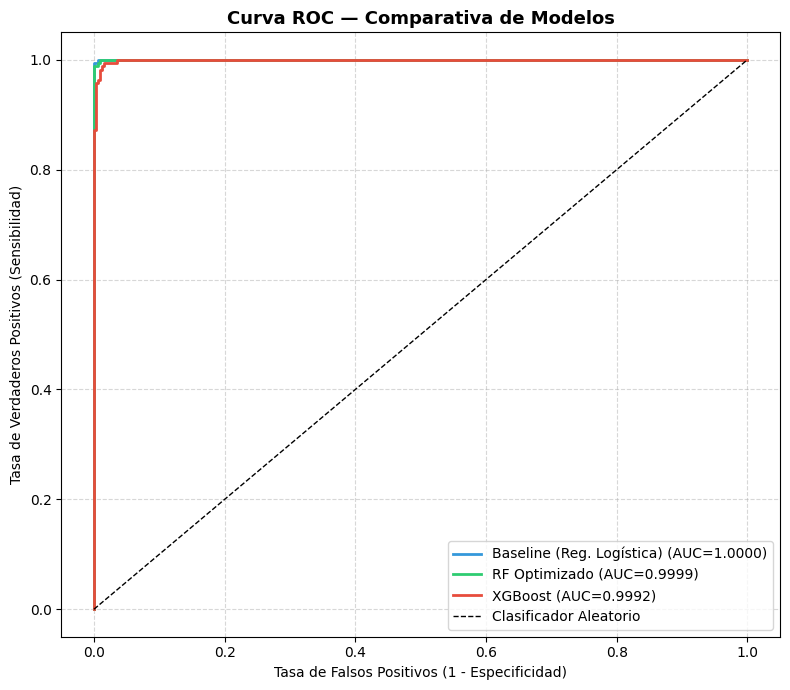

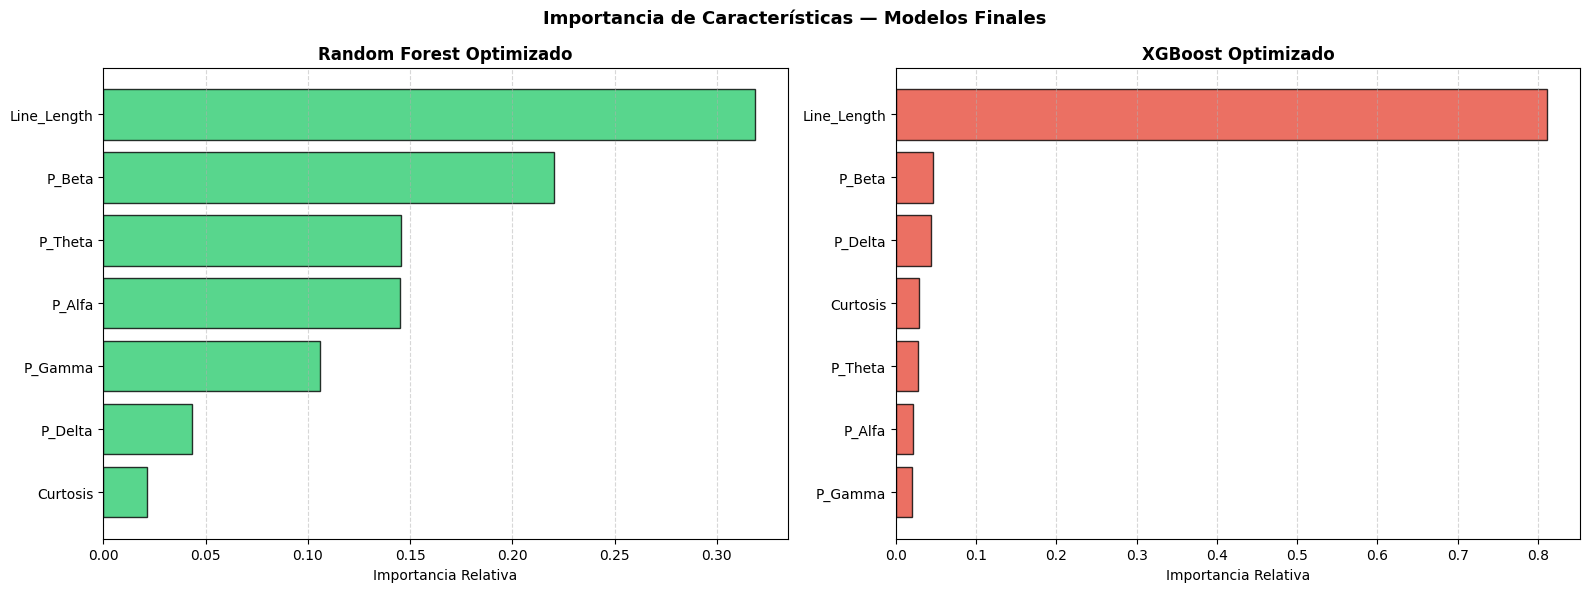


[6/7] Evaluación final en TEST...
   EVALUACIÓN FINAL EN CONJUNTO DE TEST — RANDOM FOREST (umbral=0.5)


,Métrica,Random Forest Optimizado (umbral=0.5) — TEST
0,Accuracy,0.9636
1,Precision,0.9742
2,Sensibilidad (Recall),0.9152
3,Especificidad,0.9879
4,F1-Score,0.9437
5,AUC-ROC,0.9975
6,Falsos Negativos,14.0000
7,Falsos Positivos,4.0000


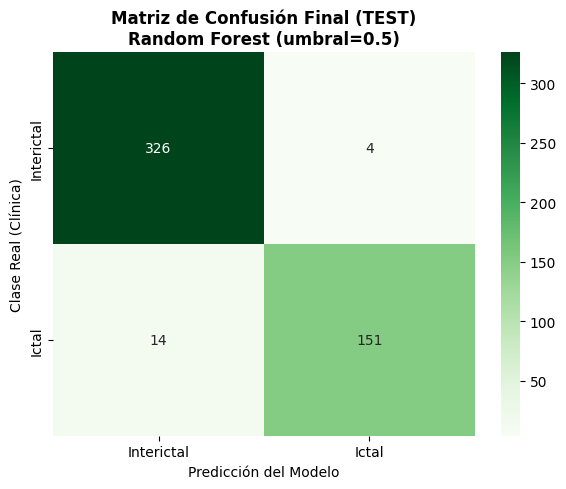


   INTERVALOS DE CONFIANZA EN TEST (Bootstrap, IC 95%)

  Remuestreos válidos: 1000 de 1000
  Tamaño del conjunto de test: 495 ventanas



,Métrica,Valor (test),Media Bootstrap,IC 95% inferior,IC 95% superior
0,Accuracy,0.9636,0.9634,0.9474,0.9778
1,Precision,0.9742,0.9738,0.9454,0.9939
2,Sensibilidad (Recall),0.9152,0.9143,0.8704,0.9515
3,Especificidad,0.9879,0.9878,0.9739,0.9971
4,F1-Score,0.9437,0.9430,0.9158,0.9667
5,AUC-ROC,0.9975,0.9975,0.9951,0.9992


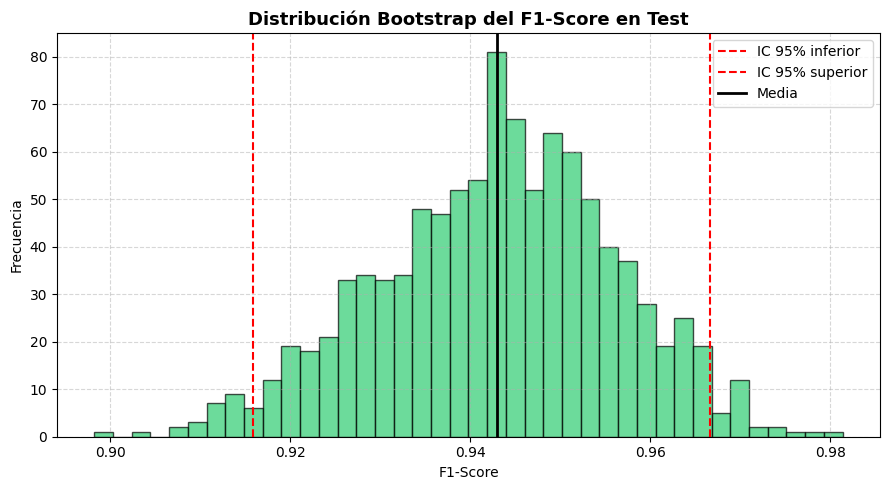


  >> F1-Score en test: 0.9437  (IC 95%: 0.9158 – 0.9667)
  >> Interpretación: con 95% de confianza, el F1 real del modelo en datos
     no vistos estaría aproximadamente entre 0.916 y 0.967.

[7/7] Exportando artefactos...
✅ Pipeline completo. Artefactos guardados:
   - modelo_rf_optimizado_eeg.pkl     (modelo definitivo)
   - modelo_xgboost_eeg.pkl           (alternativo)
   - modelo_baseline_eeg.pkl
   - escalador_robusto.pkl
   - selector_caracteristicas_k7.pkl


In [ ]:
###### EXPERIMENTO 1: SE MANTIENEN LAS MISMAS VARIABLES DE LA EXPOSICIÓN.
###### Flujo: ENVENTANAMIENTO -> ROBUSTSCALER -> MAPA DE CORRELACIÓN (se elimina
###### Varianza por alta correlación con Line_Length) -> BÚSQUEDA DE K ÓPTIMO
###### (estabilización en k=7) -> SELECCIÓN DE CARACTERÍSTICAS -> BALANCE DE
###### CLASES CON SMOTE (solo en Train, DESPUÉS de seleccionar = orden óptimo) ->
###### ENTRENAMIENTO RF + XGBOOST (umbral 0.5 para ambos) -> TEST FINAL (solo RF,
###### elegido por su mejor desempeño en VALIDACIÓN).

# =====================================================================
# IMPORTS (todos consolidados al inicio)
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from imblearn.over_sampling import SMOTE
from IPython.display import display
import xgboost as xgb

# Ignorar warnings para gráficos y salidas limpias
warnings.filterwarnings('ignore')

# =====================================================================
# PARTE A — PREPARACIÓN, SELECCIÓN DE K Y RANKING DE CARACTERÍSTICAS
#           (sobre datos REALES, sin SMOTE: el ranking debe reflejar
#            la distribución original de los datos)
# =====================================================================
print("--- INICIANDO OPTIMIZACIÓN DEL PIPELINE (FEEDBACK) ---")

# ---------------------------------------------------------------------
# 1. ENVENTANADO (EPOCHING): Ventanas de 2 segundos
# ---------------------------------------------------------------------
print("\n[1/4] Aplicando enventanado (Epoching) de 2 segundos...")

def epoch_dataset(X_raw, y_raw, window_sec, fs):
    window_samples = int(window_sec * fs)
    X_epoched, y_epoched = [], []
    for sig, label in zip(X_raw, y_raw):
        n_windows = len(sig) // window_samples
        for i in range(n_windows):
            start_idx = i * window_samples
            end_idx = start_idx + window_samples
            X_epoched.append(sig[start_idx:end_idx])
            y_epoched.append(label)
    return np.array(X_epoched), np.array(y_epoched)

window_size_sec = 2.0
X_train_ep, y_train_ep = epoch_dataset(X_train_raw, y_train, window_size_sec, fs)

print(f" -> Registros originales (Train): {X_train_raw.shape[0]}")
print(f" -> Nuevos registros (Train Epoched): {X_train_ep.shape[0]}")

# ---------------------------------------------------------------------
# 2. EXTRACCIÓN DE CARACTERÍSTICAS (sobre los nuevos datos)
# ---------------------------------------------------------------------
print("\n[2/4] Extrayendo características de las nuevas ventanas...")
X_train_feat_ep = np.array([extract_features(sig, fs) for sig in X_train_ep])
df_features_ep = pd.DataFrame(X_train_feat_ep, columns=feature_names)

# ---------------------------------------------------------------------
# 3. MAPA DE CORRELACIÓN (revisión de redundancia)
# ---------------------------------------------------------------------
print("\n[3/4] Generando Mapa de Correlación de características...")

corr_matrix = df_features_ep.corr()
plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # tapar triángulo superior
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f",
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Mapa de Correlación (Características en Ventanas de 2s)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4. VALIDACIÓN DEL K ÓPTIMO (Cross-Validation, sobre datos reales)
# ---------------------------------------------------------------------
print("\n[4/4] Evaluando el número óptimo de características (k)...")

# Estandarización (RobustScaler ajustado solo en Train)
scaler_ep = RobustScaler()
X_train_scaled_ep = scaler_ep.fit_transform(X_train_feat_ep)

cv_scores_mean = []
cv_scores_std = []
k_values = range(1, len(feature_names) + 1)
clf_eval = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=50)

for k in k_values:
    selector_temp = SelectKBest(score_func=f_classif, k=k)
    X_train_temp = selector_temp.fit_transform(X_train_scaled_ep, y_train_ep)
    scores = cross_val_score(clf_eval, X_train_temp, y_train_ep, cv=5, scoring='accuracy')
    cv_scores_mean.append(scores.mean())
    cv_scores_std.append(scores.std())

plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores_mean, marker='o', color='#2ecc71', linewidth=2, label='Exactitud Media (Accuracy)')
plt.fill_between(k_values,
                 np.array(cv_scores_mean) - np.array(cv_scores_std),
                 np.array(cv_scores_mean) + np.array(cv_scores_std),
                 color='#2ecc71', alpha=0.2, label='Desviación Estándar (Varianza)')
plt.title('Rendimiento del Modelo vs. Número de Características (k)', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Características Seleccionadas (k)', fontsize=12)
plt.ylabel('Exactitud de Validación Cruzada', fontsize=12)
plt.xticks(k_values)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(cv_scores_mean)]
max_acc = np.max(cv_scores_mean)
print(f"\n✅ El 'k' que maximiza el rendimiento es k={best_k} (Exactitud media: {max_acc:.2%}).")
print("Nota: Si el rendimiento se estanca antes, conviene elegir el 'k' menor (modelo más simple).")

# Eliminar 'Varianza' por ser redundante con 'Line_Length' (correlación ~0.92)
if 'Varianza' in feature_names:
    idx_varianza = feature_names.index('Varianza')
    X_train_scaled_ep_clean = np.delete(X_train_scaled_ep, idx_varianza, axis=1)
    feature_names_clean = feature_names.copy()
    feature_names_clean.pop(idx_varianza)
else:
    X_train_scaled_ep_clean = X_train_scaled_ep
    feature_names_clean = feature_names

# Ranking de F-Scores con el k elegido (k=7)
k_final = 7
selector_definitivo = SelectKBest(score_func=f_classif, k=k_final)
selector_definitivo.fit(X_train_scaled_ep_clean, y_train_ep)

df_scores_nuevos = pd.DataFrame({
    'Característica': feature_names_clean,
    'F-Score_Nuevo': selector_definitivo.scores_
}).sort_values(by='F-Score_Nuevo', ascending=False)

print("--- RANKING DEFINITIVO (Datos enventanados y sin Varianza) ---")
display(df_scores_nuevos)

indices_ganadores = selector_definitivo.get_support(indices=True)
caracteristicas_finales = [feature_names_clean[i] for i in indices_ganadores]
print(f"\nLas {k_final} características seleccionadas son:")
for feat in caracteristicas_finales:
    print(f"- {feat}")

# =====================================================================
# PARTE B — FASE 6: RF OPTIMIZADO + XGBOOST + SMOTE + UMBRAL (k=7)
# =====================================================================
print("\n" + "=" * 70)
print("   FASE 6 MEJORADA: RF OPTIMIZADO + XGBOOST + SMOTE + UMBRAL (k=7)")
print("=" * 70)

# ---------------------------------------------------------------------
# 0. PREPARACIÓN PREVIA: Sincronizar Validación y Prueba
# ---------------------------------------------------------------------
print("\n[0/7] Preparando conjuntos Val y Test (enventanado + features)...")

X_val_ep,  y_val_ep  = epoch_dataset(X_val_raw,  y_val,  window_size_sec, fs)
X_test_ep, y_test_ep = epoch_dataset(X_test_raw, y_test, window_size_sec, fs)

X_val_feat_ep  = np.array([extract_features(sig, fs) for sig in X_val_ep])
X_test_feat_ep = np.array([extract_features(sig, fs) for sig in X_test_ep])

# Escalado con el scaler entrenado en Train (previene data leakage)
X_val_scaled_ep  = scaler_ep.transform(X_val_feat_ep)
X_test_scaled_ep = scaler_ep.transform(X_test_feat_ep)

# Eliminar 'Varianza' en los tres conjuntos
X_val_scaled_ep_clean  = np.delete(X_val_scaled_ep,  idx_varianza, axis=1)
X_test_scaled_ep_clean = np.delete(X_test_scaled_ep, idx_varianza, axis=1)

# ---------------------------------------------------------------------
# 1. SELECCIÓN DE CARACTERÍSTICAS CON k=7
#    (PRIMERO seleccionar; el balanceo viene después)
# ---------------------------------------------------------------------
print("[1/7] Seleccionando k=7 características...")

X_train_final_model = selector_definitivo.transform(X_train_scaled_ep_clean)
X_val_final_model   = selector_definitivo.transform(X_val_scaled_ep_clean)
X_test_final_model  = selector_definitivo.transform(X_test_scaled_ep_clean)

print(f"  Dimensiones finales de entrenamiento: {X_train_final_model.shape}")
print(f"  Dimensiones finales de validación:    {X_val_final_model.shape}")
print(f"  Características seleccionadas (k={k_final}): {caracteristicas_finales}")

# ---------------------------------------------------------------------
# 2. BALANCE DE CLASES CON SMOTE
#    ORDEN ÓPTIMO: se aplica DESPUÉS de seleccionar características y
#    SOLO sobre el conjunto de entrenamiento (nunca val/test).
# ---------------------------------------------------------------------
print("\n[2/7] Evaluando desbalance de clases y aplicando SMOTE...")

unique_tr, counts_tr = np.unique(y_train_ep, return_counts=True)
print(f"  Antes de SMOTE -> Interictal (0): {counts_tr[0]} | Ictal (1): {counts_tr[1]}")
print(f"  Ratio de desbalance: {counts_tr[0]/counts_tr[1]:.2f}:1")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_final_model, y_train_ep)

unique_sm, counts_sm = np.unique(y_train_smote, return_counts=True)
print(f"  Después de SMOTE -> Interictal: {counts_sm[0]} | Ictal: {counts_sm[1]} (balanceado)")

# ---------------------------------------------------------------------
# 3. ENTRENAMIENTO DE MODELOS
# ---------------------------------------------------------------------
print("\n[3/7] Entrenando modelos...")

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 3A. Baseline: Regresión Logística ---
print("  [A] Baseline (Regresión Logística con class_weight='balanced')...")
model_baseline = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_baseline.fit(X_train_smote, y_train_smote)

# --- 3B. Random Forest con búsqueda de hiperparámetros ---
print("  [B] Random Forest — RandomizedSearchCV (20 combinaciones, CV=5)...")
param_grid_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', None]
}
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=20, scoring='f1', cv=cv_strat,
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_smote, y_train_smote)
model_rf_opt = rf_search.best_estimator_
print(f"      Mejores hiperparámetros RF: {rf_search.best_params_}")
print(f"      Mejor F1 en CV: {rf_search.best_score_:.4f}")

# --- 3C. XGBoost con búsqueda de hiperparámetros ---
print("  [C] XGBoost — RandomizedSearchCV (20 combinaciones, CV=5)...")
n_neg = np.sum(y_train_smote == 0)
n_pos = np.sum(y_train_smote == 1)
spw   = n_neg / n_pos  # scale_pos_weight (≈1 tras SMOTE)

param_grid_xgb = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, eval_metric='logloss',
                                scale_pos_weight=spw, use_label_encoder=False),
    param_distributions=param_grid_xgb,
    n_iter=20, scoring='f1', cv=cv_strat,
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train_smote, y_train_smote)
model_xgb_opt = xgb_search.best_estimator_
print(f"      Mejores hiperparámetros XGBoost: {xgb_search.best_params_}")
print(f"      Mejor F1 en CV: {xgb_search.best_score_:.4f}")

# ---------------------------------------------------------------------
# 4. FUNCIÓN DE MÉTRICAS CON UMBRAL AJUSTABLE
# ---------------------------------------------------------------------
def calcular_metricas_clinicas(model, X_val, y_val, threshold=0.5):
    """
    Evalúa un modelo con umbral de decisión ajustable.
    threshold < 0.5 aumenta la Sensibilidad (menos Falsos Negativos),
    a costa de más Falsos Positivos. Útil en contexto clínico.
    """
    y_probs = model.predict_proba(X_val)[:, 1]
    y_pred  = (y_probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

    metrics = {
        'Accuracy':              accuracy_score(y_val, y_pred),
        'Precision':             precision_score(y_val, y_pred, zero_division=0),
        'Sensibilidad (Recall)': recall_score(y_val, y_pred, zero_division=0),
        'Especificidad':         tn / (tn + fp) if (tn + fp) > 0 else 0,
        'F1-Score':              f1_score(y_val, y_pred, zero_division=0),
        'AUC-ROC':               roc_auc_score(y_val, y_probs),
        'Falsos Negativos':      int(fn),
        'Falsos Positivos':      int(fp)
    }
    return metrics, y_pred

# ---------------------------------------------------------------------
# 5. EVALUACIÓN EN VALIDACIÓN
#    Comparación JUSTA: los tres modelos al MISMO umbral (0.5).
#    Esta es la fase donde se ELIGE el modelo definitivo.
# ---------------------------------------------------------------------
print("\n[4/7] Evaluando modelos sobre el conjunto de validación...")

metrics_base, y_pred_base = calcular_metricas_clinicas(model_baseline, X_val_final_model, y_val_ep, threshold=0.5)
metrics_rf,   y_pred_rf   = calcular_metricas_clinicas(model_rf_opt,   X_val_final_model, y_val_ep, threshold=0.5)
metrics_xgb,  y_pred_xgb  = calcular_metricas_clinicas(model_xgb_opt,  X_val_final_model, y_val_ep, threshold=0.5)

df_comparativo = pd.DataFrame({
    'Métrica':                   list(metrics_base.keys()),
    'Baseline (Reg. Logística)': [round(v, 4) for v in metrics_base.values()],
    'RF Optimizado':             [round(v, 4) for v in metrics_rf.values()],
    'XGBoost Optimizado':        [round(v, 4) for v in metrics_xgb.values()]
})
print("\n" + "="*70)
print("   TABLA COMPARATIVA DE RENDIMIENTO (VALIDACIÓN, umbral=0.5 en todos)")
print("="*70)
display(df_comparativo)
print("\n>> Random Forest obtiene el mejor F1 y menos Falsos Negativos en validación.")
print(">> Se elige RANDOM FOREST como modelo definitivo para la evaluación en TEST.")

# ---------------------------------------------------------------------
# 6. VISUALIZACIONES
# ---------------------------------------------------------------------
print("\n[5/7] Generando visualizaciones...")

# --- Matrices de confusión (3 modelos a umbral 0.5) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión — Comparativa (Validación, umbral=0.5)',
             fontsize=14, fontweight='bold')
configs = [
    (y_pred_base, 'Baseline\n(Reg. Logística)', 'Blues'),
    (y_pred_rf,   'RF Optimizado',              'Greens'),
    (y_pred_xgb,  'XGBoost Optimizado',         'Oranges'),
]
for ax, (y_pred, title, cmap) in zip(axes, configs):
    cm = confusion_matrix(y_val_ep, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['Interictal', 'Ictal'],
                yticklabels=['Interictal', 'Ictal'])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Clase Real')
plt.tight_layout()
plt.show()

# --- Curva ROC comparativa ---
fig, ax = plt.subplots(figsize=(8, 7))
for model, label, color in [
    (model_baseline, 'Baseline (Reg. Logística)', '#3498db'),
    (model_rf_opt,   'RF Optimizado',             '#2ecc71'),
    (model_xgb_opt,  'XGBoost',                   '#e74c3c'),
]:
    probs = model.predict_proba(X_val_final_model)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_ep, probs)
    auc = roc_auc_score(y_val_ep, probs)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.4f})', linewidth=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
ax.set_title('Curva ROC — Comparativa de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- Importancia de características (RF y XGBoost) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importancia de Características — Modelos Finales', fontsize=13, fontweight='bold')
for ax, model, title, color in [
    (axes[0], model_rf_opt,  'Random Forest Optimizado', '#2ecc71'),
    (axes[1], model_xgb_opt, 'XGBoost Optimizado',       '#e74c3c'),
]:
    df_imp = pd.DataFrame({
        'Característica': caracteristicas_finales,
        'Importancia':    model.feature_importances_
    }).sort_values('Importancia', ascending=True)
    ax.barh(df_imp['Característica'], df_imp['Importancia'], color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Importancia Relativa')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 7. EVALUACIÓN FINAL EN TEST (una sola vez)
#    Modelo definitivo: RANDOM FOREST (elegido por validación), umbral 0.5.
# ---------------------------------------------------------------------
print("\n[6/7] Evaluación final en TEST...")
print("="*70)
print("   EVALUACIÓN FINAL EN CONJUNTO DE TEST — RANDOM FOREST (umbral=0.5)")
print("="*70)

metrics_test_rf, y_pred_test_rf = calcular_metricas_clinicas(
    model_rf_opt, X_test_final_model, y_test_ep, threshold=0.5
)
df_test_rf = pd.DataFrame({
    'Métrica': list(metrics_test_rf.keys()),
    'Random Forest Optimizado (umbral=0.5) — TEST': [round(v, 4) for v in metrics_test_rf.values()]
})
display(df_test_rf)

# Matriz de confusión final en test (solo RF)
plt.figure(figsize=(6, 5))
cm_test_rf = confusion_matrix(y_test_ep, y_pred_test_rf)
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Interictal', 'Ictal'], yticklabels=['Interictal', 'Ictal'])
plt.title('Matriz de Confusión Final (TEST)\nRandom Forest (umbral=0.5)', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Clínica)')
plt.tight_layout()
plt.show()

# =====================================================================
# INTERVALOS DE CONFIANZA EN TEST (Bootstrap)
# =====================================================================
# Estima la incertidumbre de las métricas de test remuestreando con
# reemplazo el conjunto de test 'n_boot' veces. Reporta media e IC 95%.
# =====================================================================
from sklearn.utils import resample

print("\n" + "="*70)
print("   INTERVALOS DE CONFIANZA EN TEST (Bootstrap, IC 95%)")
print("="*70)

# ---------------- CONFIG (ajustar por experimento) -------------------
modelo_final = model_rf_opt          # modelo elegido en validación
X_test_eval  = X_test_final_model
y_test_eval  = y_test_ep
THRESHOLD    = 0.5
n_boot       = 1000
# ---------------------------------------------------------------------

# Probabilidades predichas una sola vez (no cambian entre remuestreos)
y_probs_full = modelo_final.predict_proba(X_test_eval)[:, 1]
y_pred_full  = (y_probs_full >= THRESHOLD).astype(int)
y_true_full  = np.asarray(y_test_eval)
n            = len(y_true_full)

# Acumuladores por métrica
boot_metrics = {
    'Accuracy': [], 'Precision': [], 'Sensibilidad (Recall)': [],
    'Especificidad': [], 'F1-Score': [], 'AUC-ROC': []
}

rng = np.random.RandomState(42)
for _ in range(n_boot):
    # Remuestreo con reemplazo de los ÍNDICES del test
    idx = resample(np.arange(n), replace=True, n_samples=n, random_state=rng.randint(0, 1_000_000))

    yt = y_true_full[idx]
    yp = y_pred_full[idx]
    pr = y_probs_full[idx]

    # Si el remuestreo dejó una sola clase, se descarta (métricas indefinidas)
    if len(np.unique(yt)) < 2:
        continue

    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

    boot_metrics['Accuracy'].append(accuracy_score(yt, yp))
    boot_metrics['Precision'].append(precision_score(yt, yp, zero_division=0))
    boot_metrics['Sensibilidad (Recall)'].append(recall_score(yt, yp, zero_division=0))
    boot_metrics['Especificidad'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    boot_metrics['F1-Score'].append(f1_score(yt, yp, zero_division=0))
    boot_metrics['AUC-ROC'].append(roc_auc_score(yt, pr))

# Construir tabla resumen: valor puntual + media bootstrap + IC 95%
filas = []
for metrica, valores in boot_metrics.items():
    valores = np.array(valores)
    # Valor puntual sobre el test completo (sin remuestrear)
    if metrica == 'AUC-ROC':
        punto = roc_auc_score(y_true_full, y_probs_full)
    elif metrica == 'Especificidad':
        tn, fp, fn, tp = confusion_matrix(y_true_full, y_pred_full, labels=[0, 1]).ravel()
        punto = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        func = {'Accuracy': accuracy_score, 'Precision': precision_score,
                'Sensibilidad (Recall)': recall_score, 'F1-Score': f1_score}[metrica]
        punto = func(y_true_full, y_pred_full, zero_division=0) if metrica != 'Accuracy' \
                else accuracy_score(y_true_full, y_pred_full)

    ic_low  = np.percentile(valores, 2.5)
    ic_high = np.percentile(valores, 97.5)
    filas.append({
        'Métrica':        metrica,
        'Valor (test)':   round(punto, 4),
        'Media Bootstrap':round(valores.mean(), 4),
        'IC 95% inferior':round(ic_low, 4),
        'IC 95% superior':round(ic_high, 4)
    })

df_ic = pd.DataFrame(filas)
print(f"\n  Remuestreos válidos: {len(boot_metrics['F1-Score'])} de {n_boot}")
print(f"  Tamaño del conjunto de test: {n} ventanas\n")
display(df_ic)

# --- Visualización: F1 con su distribución bootstrap ---
plt.figure(figsize=(9, 5))
f1_boot = np.array(boot_metrics['F1-Score'])
plt.hist(f1_boot, bins=40, color='#2ecc71', alpha=0.7, edgecolor='black')
plt.axvline(np.percentile(f1_boot, 2.5),  color='red', linestyle='--', label='IC 95% inferior')
plt.axvline(np.percentile(f1_boot, 97.5), color='red', linestyle='--', label='IC 95% superior')
plt.axvline(f1_boot.mean(), color='black', linestyle='-', linewidth=2, label='Media')
plt.title('Distribución Bootstrap del F1-Score en Test', fontsize=13, fontweight='bold')
plt.xlabel('F1-Score')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Resumen interpretable
f1_punto = df_ic.loc[df_ic['Métrica'] == 'F1-Score', 'Valor (test)'].values[0]
f1_low   = df_ic.loc[df_ic['Métrica'] == 'F1-Score', 'IC 95% inferior'].values[0]
f1_high  = df_ic.loc[df_ic['Métrica'] == 'F1-Score', 'IC 95% superior'].values[0]
print(f"\n  >> F1-Score en test: {f1_punto:.4f}  (IC 95%: {f1_low:.4f} – {f1_high:.4f})")
print( "  >> Interpretación: con 95% de confianza, el F1 real del modelo en datos")
print(f"     no vistos estaría aproximadamente entre {f1_low:.3f} y {f1_high:.3f}.")

# ---------------------------------------------------------------------
# 8. EXPORTACIÓN DE ARTEFACTOS
# ---------------------------------------------------------------------
print("\n[7/7] Exportando artefactos...")
joblib.dump(model_rf_opt,         'modelo_rf_optimizado_eeg.pkl')   # modelo definitivo
joblib.dump(model_xgb_opt,        'modelo_xgboost_eeg.pkl')         # alternativo (entrenado, no elegido)
joblib.dump(model_baseline,       'modelo_baseline_eeg.pkl')
joblib.dump(scaler_ep,            'escalador_robusto.pkl')
joblib.dump(selector_definitivo,  'selector_caracteristicas_k7.pkl')
print("✅ Pipeline completo. Artefactos guardados:")
print("   - modelo_rf_optimizado_eeg.pkl     (modelo definitivo)")
print("   - modelo_xgboost_eeg.pkl           (alternativo)")
print("   - modelo_baseline_eeg.pkl")
print("   - escalador_robusto.pkl")
print("   - selector_caracteristicas_k7.pkl")

resultados_exp1 = {'metricas': metrics_test_rf, 'ic': df_ic, 'nombre': 'Exp. 1 — 9 características (k=7)'}

   FASE 6 MEJORADA: PIPELINE OPTIMIZADO (SMOTE EN ORDEN ÓPTIMO)

Total de características en la nueva versión: 20

[1/6] Enventanado y extracción de características (v2) en Train/Val/Test...
      (Esto puede tardar ~2-3 min por las nuevas características no-lineales)

  Distribución post-enventanado (Train):
  Interictal (0): 1529 | Ictal (1): 770
  Ratio de desbalance: 1.99:1

[CORR] Analizando correlación entre las 20 características...


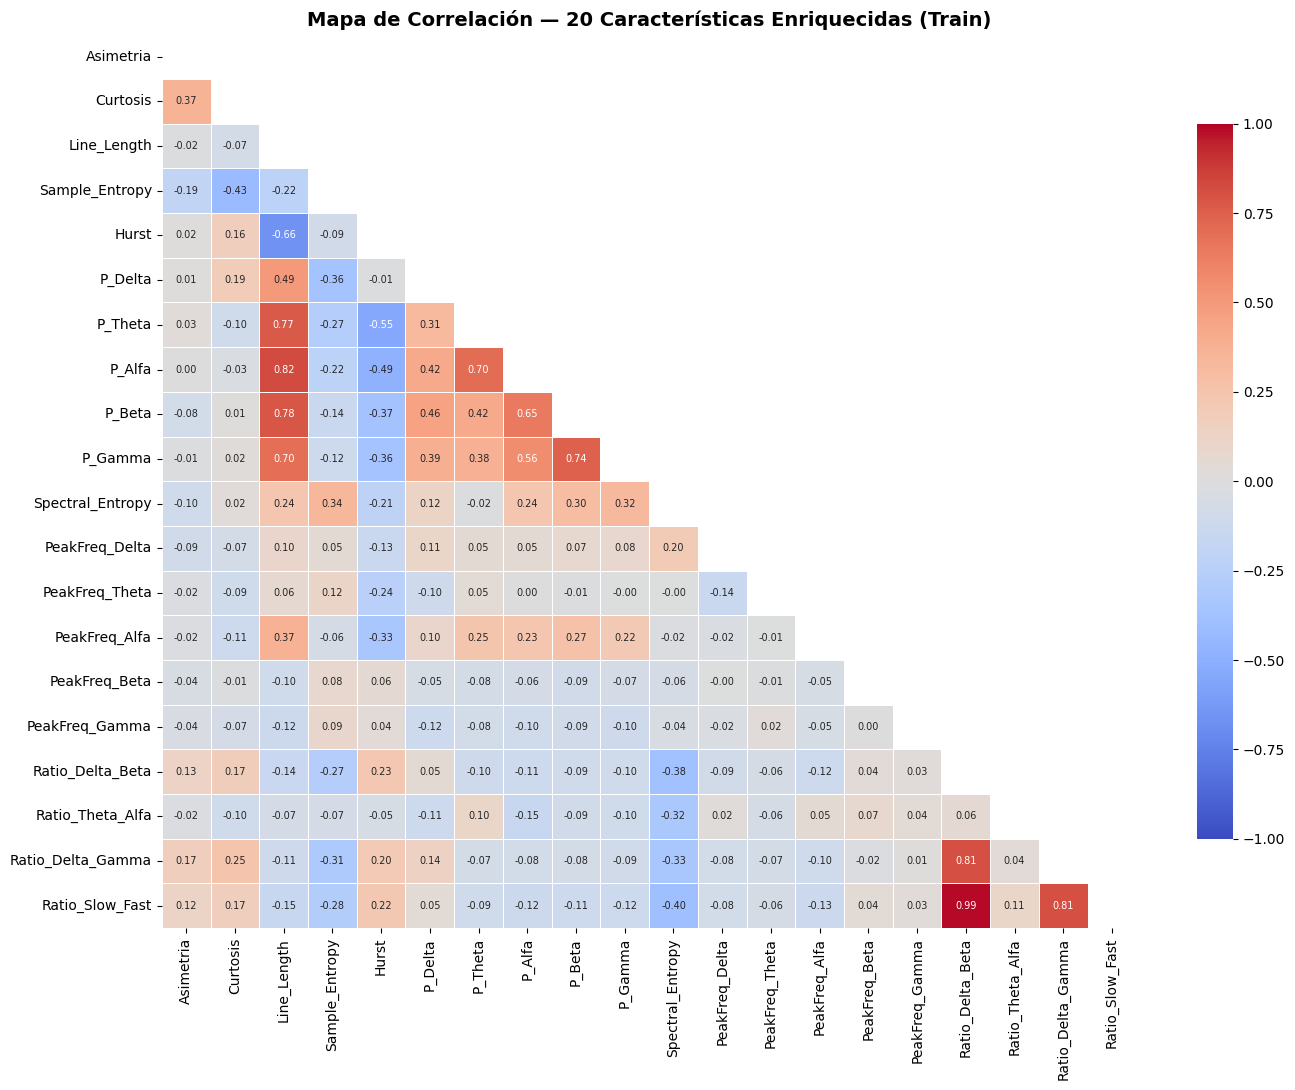


  Pares con |correlación| >= 0.8:
    Line_Length        <-> P_Alfa             r = +0.824
    Ratio_Delta_Beta   <-> Ratio_Delta_Gamma  r = +0.808
    Ratio_Delta_Beta   <-> Ratio_Slow_Fast    r = +0.992
    Ratio_Delta_Gamma  <-> Ratio_Slow_Fast    r = +0.811

  Sugerencia: eliminar 3 característica(s) redundante(s):
    - Ratio_Delta_Gamma (F-Score=47.6)
    - Ratio_Delta_Beta (F-Score=76.1)
    - P_Alfa (F-Score=1052.7)

  Características restantes: 17
  ['Asimetria', 'Curtosis', 'Line_Length', 'Sample_Entropy', 'Hurst', 'P_Delta', 'P_Theta', 'P_Beta', 'P_Gamma', 'Spectral_Entropy', 'PeakFreq_Delta', 'PeakFreq_Theta', 'PeakFreq_Alfa', 'PeakFreq_Beta', 'PeakFreq_Gamma', 'Ratio_Theta_Alfa', 'Ratio_Slow_Fast']

[2/6] Estandarizando con RobustScaler...

[3/6] Evaluando el número óptimo de características (k) sobre datos reales...


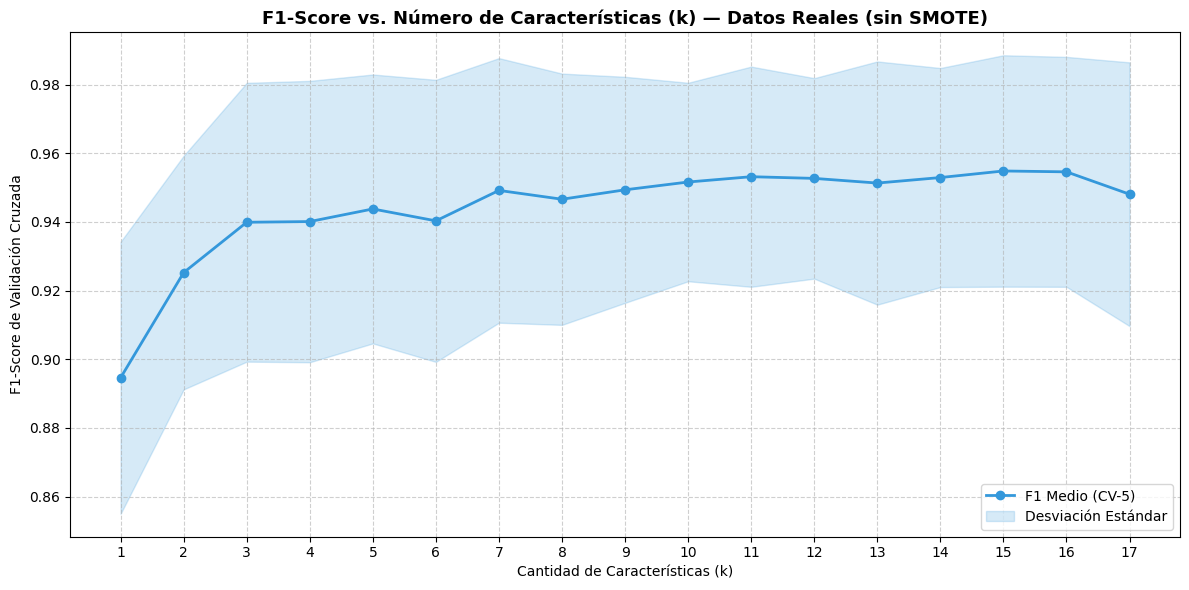


  k óptimo detectado automáticamente: k=15
  Nota: NO se escoge ese valor; se ajusta manualmente a k=6 porque ahí la curva se estabiliza.
  Nota: Se prefiere k=6 para evitar overfitting (modelo más simple).

[4/6] Seleccionando k=6 características y luego aplicando SMOTE...

  Ranking definitivo (Top características):


,Característica,F-Score
2,Line_Length,3568.975888
4,Hurst,1648.397554
6,P_Theta,1049.406639
8,P_Gamma,635.268805
7,P_Beta,617.341887
12,PeakFreq_Alfa,398.393029



  Características seleccionadas para el modelo: ['Line_Length', 'Hurst', 'P_Theta', 'P_Beta', 'P_Gamma', 'PeakFreq_Alfa']

  Aplicando SMOTE sobre las características seleccionadas (solo Train)...
  Antes de SMOTE -> Interictal: 1529 | Ictal: 770
  Post-SMOTE     -> Interictal: 1529 | Ictal: 1529 (balanceado)

[5/6] Entrenando modelos...
  [A] Entrenando Baseline (Regresión Logística)...
  [B] Buscando hiperparámetros óptimos para Random Forest...
      (RandomizedSearchCV con 20 combinaciones, CV=5 — tarda ~3 min)
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  Mejores hiperparámetros RF: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}
  Mejor F1 en CV: 0.9779

  [C] Entrenando XGBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

  Mejores hiperparámetros XGBoost: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate

,Métrica,Baseline (Reg. Logística),RF Optimizado,XGBoost Optimizado
0,Accuracy,0.9862,0.9941,0.9862
1,Precision,0.9938,1.0000,0.9877
2,Sensibilidad (Recall),0.9636,0.9818,0.9697
3,Especificidad,0.9971,1.0000,0.9941
4,F1-Score,0.9785,0.9908,0.9786
5,AUC-ROC,0.9999,0.9999,0.9990
6,Falsos Negativos,6.0000,3.0000,5.0000
7,Falsos Positivos,1.0000,0.0000,2.0000



>> Random Forest obtiene el mejor F1 y menos Falsos Negativos en validación.
>> Se elige RANDOM FOREST como modelo definitivo para la evaluación en TEST.


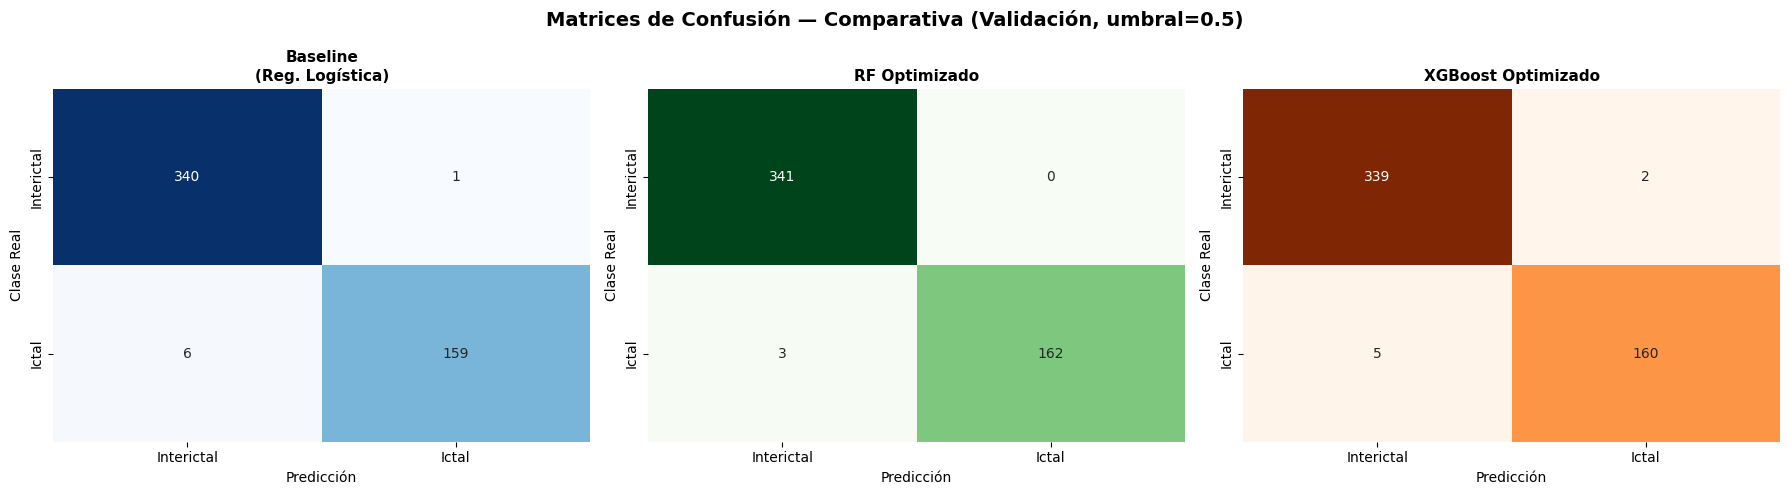

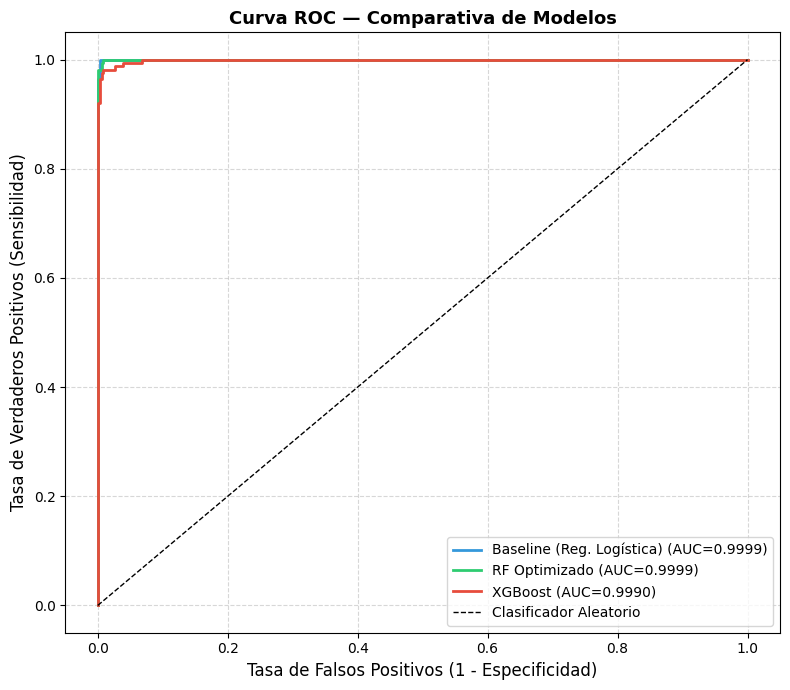

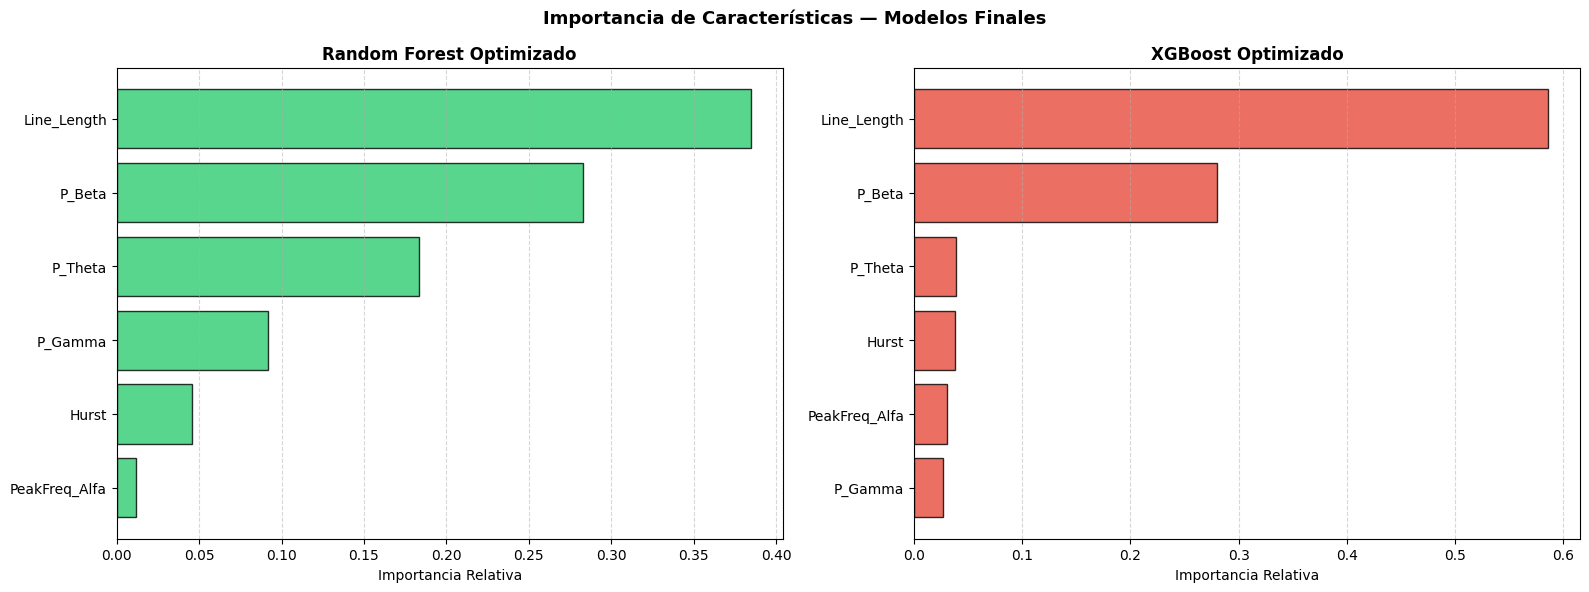


   EVALUACIÓN FINAL EN CONJUNTO DE TEST — RANDOM FOREST (umbral=0.5)


,Métrica,Random Forest Optimizado (umbral=0.5) — TEST
0,Accuracy,0.9737
1,Precision,0.9872
2,Sensibilidad (Recall),0.9333
3,Especificidad,0.9939
4,F1-Score,0.9595
5,AUC-ROC,0.9972
6,Falsos Negativos,11.0000
7,Falsos Positivos,2.0000


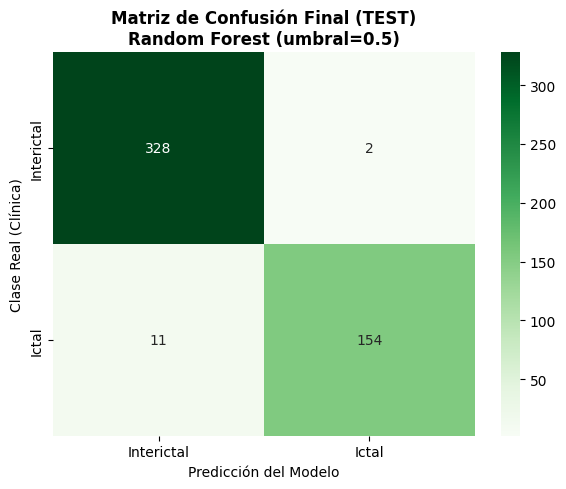


   INTERVALOS DE CONFIANZA EN TEST (Bootstrap, IC 95%)

  Remuestreos válidos: 1000 de 1000
  Tamaño del conjunto de test: 495 ventanas



,Métrica,Valor (test),Media Bootstrap,IC 95% inferior,IC 95% superior
0,Accuracy,0.9737,0.9736,0.9596,0.9859
1,Precision,0.9872,0.9867,0.9634,1.0000
2,Sensibilidad (Recall),0.9333,0.9329,0.8931,0.9684
3,Especificidad,0.9939,0.9938,0.9826,1.0000
4,F1-Score,0.9595,0.9589,0.9342,0.9797
5,AUC-ROC,0.9972,0.9972,0.9946,0.9990


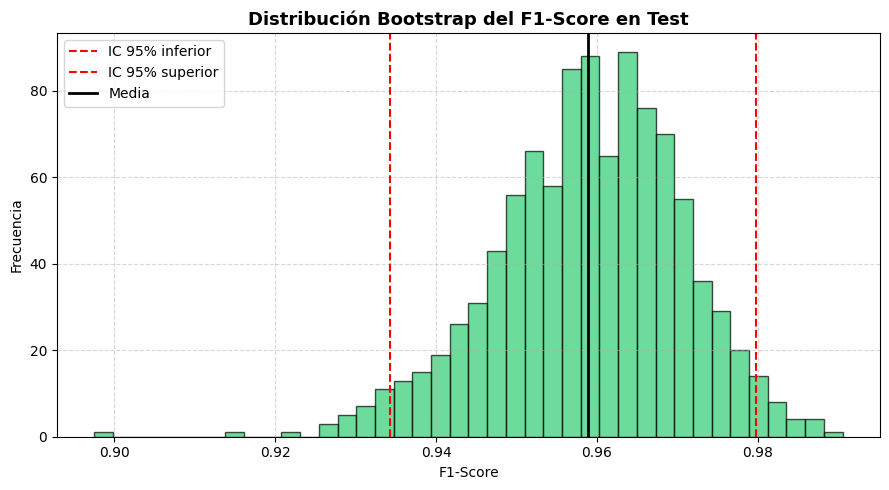


  >> F1-Score en test: 0.9595  (IC 95%: 0.9342 – 0.9797)
  >> Interpretación: con 95% de confianza, el F1 real del modelo en datos
     no vistos estaría aproximadamente entre 0.934 y 0.980.

Exportando artefactos del pipeline...
✅ Pipeline completo. Artefactos guardados:
   - modelo_rf_optimizado_eeg_v2.pkl  (modelo definitivo)
   - modelo_xgboost_eeg_v2.pkl        (alternativo)
   - modelo_baseline_eeg_v2.pkl
   - escalador_robusto_v2.pkl
   - selector_caracteristicas_v2.pkl


In [ ]:
### EXPERIMENTO 2 : SE INICIA CON 20 CARACTERÍSTICAS ENRIQUECIDAS.
# FLUJO ÓPTIMO: ENVENTANADO -> EXTRACCIÓN -> ROBUSTSCALER -> BÚSQUEDA DE K
# (sobre datos REALES) -> SELECCIÓN DE CARACTERÍSTICAS (k=6) -> SMOTE
# (solo en Train, DESPUÉS de seleccionar) -> ENTRENAMIENTO RF + XGBOOST ->
# TEST FINAL (solo RF, elegido por su mejor desempeño en VALIDACIÓN).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from scipy.stats import entropy, skew, kurtosis
from scipy.signal import welch
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from IPython.display import display
import xgboost as xgb

warnings.filterwarnings('ignore')

print("=" * 70)
print("   FASE 6 MEJORADA: PIPELINE OPTIMIZADO (SMOTE EN ORDEN ÓPTIMO)")
print("=" * 70)

# =====================================================================
# 0. FUNCIÓN DE EXTRACCIÓN DE CARACTERÍSTICAS ENRIQUECIDA
#    (+) Ratios entre bandas, Frecuencia pico, Entropía espectral,
#        Sample Entropy, Exponente de Hurst
#    (=) Line_Length, Asimetria, Curtosis, Potencias
#    (-) Varianza (eliminada por redundante)
# =====================================================================

window_size_sec = 2.0

def epoch_dataset(X_raw, y_raw, window_sec, fs):
    window_samples = int(window_sec * fs)
    X_epoched, y_epoched = [], []
    for sig, label in zip(X_raw, y_raw):
        n_windows = len(sig) // window_samples
        for i in range(n_windows):
            start_idx = i * window_samples
            end_idx = start_idx + window_samples
            X_epoched.append(sig[start_idx:end_idx])
            y_epoched.append(label)
    return np.array(X_epoched), np.array(y_epoched)

def sample_entropy_approx(signal, m=2, r_factor=0.2):
    """Entropía de muestra aproximada. Cae durante una crisis epiléptica."""
    r = r_factor * np.std(signal)
    N = len(signal)

    def phi(m_val):
        count = 0
        templates = np.array([signal[i:i + m_val] for i in range(N - m_val)])
        for i in range(len(templates)):
            dists = np.max(np.abs(templates - templates[i]), axis=1)
            count += np.sum(dists <= r) - 1
        return count / (N - m_val)

    phi_m  = phi(m)
    phi_m1 = phi(m + 1)
    if phi_m == 0 or phi_m1 == 0:
        return 0.0
    return -np.log(phi_m1 / phi_m)


def hurst_exponent(signal):
    """Exponente de Hurst via R/S Analysis. H>0.5 memoria, H<0.5 antipersistente."""
    N = len(signal)
    if N < 20:
        return 0.5
    max_lag = int(np.log2(N))
    lags, rs_values = [], []
    for i in range(3, max_lag):
        lag = 2 ** i
        sub_signals = [signal[j * lag:(j + 1) * lag] for j in range(N // lag)]
        rs_per_sub = []
        for sub in sub_signals:
            mean_sub = np.mean(sub)
            deviation = np.cumsum(sub - mean_sub)
            R = np.max(deviation) - np.min(deviation)
            S = np.std(sub)
            if S > 0:
                rs_per_sub.append(R / S)
        if rs_per_sub:
            lags.append(np.log(lag))
            rs_values.append(np.log(np.mean(rs_per_sub)))
    if len(lags) < 2:
        return 0.5
    H, _ = np.polyfit(lags, rs_values, 1)
    return H


def extract_features_v2(signal, fs):
    """Extracción de características enriquecida (20 características)."""
    sig_filtered = butter_bandpass_filter(signal, 0.5, 40.0, fs)

    # Temporales
    skw  = skew(sig_filtered)
    kurt = kurtosis(sig_filtered)
    line_length = np.sum(np.abs(np.diff(sig_filtered)))

    # No lineales
    samp_ent = sample_entropy_approx(sig_filtered)
    hurst    = hurst_exponent(sig_filtered)

    # Potencia por bandas
    freqs, psd = welch(sig_filtered, fs=fs, nperseg=256)
    band_powers = {}
    for band_name, (f_min, f_max) in bands.items():
        idx = np.logical_and(freqs >= f_min, freqs <= f_max)
        band_powers[band_name] = np.sum(psd[idx])

    # Entropía espectral
    psd_norm = psd / (np.sum(psd) + 1e-12)
    spectral_entropy = entropy(psd_norm + 1e-12)

    # Frecuencia pico por banda
    peak_freqs = {}
    for band_name, (f_min, f_max) in bands.items():
        idx = np.logical_and(freqs >= f_min, freqs <= f_max)
        if np.sum(idx) > 0:
            peak_freqs[band_name] = freqs[idx][np.argmax(psd[idx])]
        else:
            peak_freqs[band_name] = 0.0

    # Ratios entre bandas
    eps = 1e-12
    ratio_delta_beta  = band_powers['Delta']  / (band_powers['Beta']  + eps)
    ratio_theta_alfa  = band_powers['Theta']  / (band_powers['Alfa']  + eps)
    ratio_delta_gamma = band_powers['Delta']  / (band_powers['Gamma'] + eps)
    ratio_slow_fast   = (band_powers['Delta'] + band_powers['Theta']) / \
                        (band_powers['Beta']  + band_powers['Gamma'] + eps)

    features = [
        skw, kurt, line_length,
        samp_ent, hurst,
        band_powers['Delta'], band_powers['Theta'], band_powers['Alfa'],
        band_powers['Beta'],  band_powers['Gamma'],
        spectral_entropy,
        peak_freqs['Delta'], peak_freqs['Theta'], peak_freqs['Alfa'],
        peak_freqs['Beta'],  peak_freqs['Gamma'],
        ratio_delta_beta, ratio_theta_alfa, ratio_delta_gamma, ratio_slow_fast
    ]
    return features


feature_names_v2 = [
    'Asimetria', 'Curtosis', 'Line_Length',
    'Sample_Entropy', 'Hurst',
    'P_Delta', 'P_Theta', 'P_Alfa', 'P_Beta', 'P_Gamma',
    'Spectral_Entropy',
    'PeakFreq_Delta', 'PeakFreq_Theta', 'PeakFreq_Alfa',
    'PeakFreq_Beta',  'PeakFreq_Gamma',
    'Ratio_Delta_Beta', 'Ratio_Theta_Alfa', 'Ratio_Delta_Gamma', 'Ratio_Slow_Fast'
]

print(f"\nTotal de características en la nueva versión: {len(feature_names_v2)}")

# =====================================================================
# 1. PREPARACIÓN: Enventanado + Extracción v2 en los 3 conjuntos
# =====================================================================
print("\n[1/6] Enventanado y extracción de características (v2) en Train/Val/Test...")
print("      (Esto puede tardar ~2-3 min por las nuevas características no-lineales)")

X_train_ep, y_train_ep = epoch_dataset(X_train_raw, y_train, window_size_sec, fs)
X_val_ep,   y_val_ep   = epoch_dataset(X_val_raw,   y_val,   window_size_sec, fs)
X_test_ep,  y_test_ep  = epoch_dataset(X_test_raw,  y_test,  window_size_sec, fs)

X_train_feat_v2 = np.array([extract_features_v2(sig, fs) for sig in X_train_ep])
X_val_feat_v2   = np.array([extract_features_v2(sig, fs) for sig in X_val_ep])
X_test_feat_v2  = np.array([extract_features_v2(sig, fs) for sig in X_test_ep])

unique_train, counts_train = np.unique(y_train_ep, return_counts=True)
print(f"\n  Distribución post-enventanado (Train):")
print(f"  Interictal (0): {counts_train[0]} | Ictal (1): {counts_train[1]}")
print(f"  Ratio de desbalance: {counts_train[0]/counts_train[1]:.2f}:1")

# =====================================================================
# MAPA DE CORRELACIÓN Y ELIMINACIÓN DE VARIABLES REDUNDANTES
# =====================================================================
print("\n[CORR] Analizando correlación entre las 20 características...")

df_features_v2 = pd.DataFrame(X_train_feat_v2, columns=feature_names_v2)
corr_matrix_v2 = df_features_v2.corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix_v2, dtype=bool))
sns.heatmap(corr_matrix_v2, mask=mask, annot=True, cmap='coolwarm', fmt=".2f",
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 7},
            cbar_kws={"shrink": .8})
plt.title('Mapa de Correlación — 20 Características Enriquecidas (Train)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

UMBRAL_CORR = 0.80

print(f"\n  Pares con |correlación| >= {UMBRAL_CORR}:")
pares_altos = []
for i in range(len(feature_names_v2)):
    for j in range(i + 1, len(feature_names_v2)):
        r = corr_matrix_v2.iloc[i, j]
        if abs(r) >= UMBRAL_CORR:
            pares_altos.append((feature_names_v2[i], feature_names_v2[j], r))
            print(f"    {feature_names_v2[i]:<18} <-> {feature_names_v2[j]:<18} r = {r:+.3f}")

if not pares_altos:
    print("    (Ninguno) No hay redundancias fuertes; puedes conservar las 20.")

if pares_altos:
    f_scores, _ = f_classif(X_train_feat_v2, y_train_ep)
    f_score_dict = dict(zip(feature_names_v2, f_scores))

    a_eliminar = set()
    for feat_a, feat_b, r in pares_altos:
        if feat_a in a_eliminar or feat_b in a_eliminar:
            continue
        if f_score_dict[feat_a] >= f_score_dict[feat_b]:
            a_eliminar.add(feat_b)
        else:
            a_eliminar.add(feat_a)

    print(f"\n  Sugerencia: eliminar {len(a_eliminar)} característica(s) redundante(s):")
    for feat in a_eliminar:
        print(f"    - {feat} (F-Score={f_score_dict[feat]:.1f})")

    feature_names_v2_clean = [f for f in feature_names_v2 if f not in a_eliminar]
    indices_conservar = [feature_names_v2.index(f) for f in feature_names_v2_clean]

    X_train_feat_v2 = X_train_feat_v2[:, indices_conservar]
    X_val_feat_v2   = X_val_feat_v2[:,   indices_conservar]
    X_test_feat_v2  = X_test_feat_v2[:,  indices_conservar]

    feature_names_v2 = feature_names_v2_clean

    print(f"\n  Características restantes: {len(feature_names_v2)}")
    print(f"  {feature_names_v2}")
else:
    print("\n  No se elimina ninguna característica.")

# =====================================================================
# 2. ESTANDARIZACIÓN (RobustScaler - ajustado solo en Train)
# =====================================================================
print("\n[2/6] Estandarizando con RobustScaler...")
scaler_v2 = RobustScaler()
X_train_scaled_v2 = scaler_v2.fit_transform(X_train_feat_v2)
X_val_scaled_v2   = scaler_v2.transform(X_val_feat_v2)
X_test_scaled_v2  = scaler_v2.transform(X_test_feat_v2)

# =====================================================================
# 3. BÚSQUEDA DEL K ÓPTIMO  (sobre datos REALES, ANTES de SMOTE)
# =====================================================================
print("\n[3/6] Evaluando el número óptimo de características (k) sobre datos reales...")

cv_scores_mean_v2 = []
cv_scores_std_v2  = []
k_values_v2 = range(1, len(feature_names_v2) + 1)

for k in k_values_v2:
    selector_temp = SelectKBest(score_func=f_classif, k=k)
    X_temp_k = selector_temp.fit_transform(X_train_scaled_v2, y_train_ep)
    clf_eval_k = RandomForestClassifier(random_state=42, n_jobs=-1,
                                        n_estimators=50, class_weight='balanced')
    scores = cross_val_score(clf_eval_k, X_temp_k, y_train_ep, cv=5, scoring='f1')
    cv_scores_mean_v2.append(scores.mean())
    cv_scores_std_v2.append(scores.std())

plt.figure(figsize=(12, 6))
plt.plot(k_values_v2, cv_scores_mean_v2, marker='o', color='#3498db', linewidth=2, label='F1 Medio (CV-5)')
plt.fill_between(k_values_v2,
                 np.array(cv_scores_mean_v2) - np.array(cv_scores_std_v2),
                 np.array(cv_scores_mean_v2) + np.array(cv_scores_std_v2),
                 color='#3498db', alpha=0.2, label='Desviación Estándar')
plt.title('F1-Score vs. Número de Características (k) — Datos Reales (sin SMOTE)',
          fontsize=13, fontweight='bold')
plt.xlabel('Cantidad de Características (k)')
plt.ylabel('F1-Score de Validación Cruzada')
plt.xticks(k_values_v2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

best_k_v2 = int(k_values_v2[np.argmax(cv_scores_mean_v2)])
print(f"\n  k óptimo detectado automáticamente: k={best_k_v2}")
print("  Nota: NO se escoge ese valor; se ajusta manualmente a k=6 porque ahí la curva se estabiliza.")
print("  Nota: Se prefiere k=6 para evitar overfitting (modelo más simple).")

# =====================================================================
# 4. SELECCIÓN DE CARACTERÍSTICAS (k=6) Y LUEGO SMOTE
# =====================================================================
print("\n[4/6] Seleccionando k=6 características y luego aplicando SMOTE...")

k_final_v2 = 6
selector_v2 = SelectKBest(score_func=f_classif, k=k_final_v2)

X_train_sel = selector_v2.fit_transform(X_train_scaled_v2, y_train_ep)
X_val_final_v2  = selector_v2.transform(X_val_scaled_v2)
X_test_final_v2 = selector_v2.transform(X_test_scaled_v2)

indices_v2 = selector_v2.get_support(indices=True)
caracteristicas_v2 = [feature_names_v2[i] for i in indices_v2]
df_ranking_v2 = pd.DataFrame({
    'Característica': feature_names_v2,
    'F-Score': selector_v2.scores_
}).sort_values('F-Score', ascending=False)
print(f"\n  Ranking definitivo (Top características):")
display(df_ranking_v2.head(6))
print(f"\n  Características seleccionadas para el modelo: {caracteristicas_v2}")

print("\n  Aplicando SMOTE sobre las características seleccionadas (solo Train)...")
smote = SMOTE(random_state=42)
X_train_final_v2, y_train_smote = smote.fit_resample(X_train_sel, y_train_ep)

unique_smote, counts_smote = np.unique(y_train_smote, return_counts=True)
print(f"  Antes de SMOTE -> Interictal: {counts_train[0]} | Ictal: {counts_train[1]}")
print(f"  Post-SMOTE     -> Interictal: {counts_smote[0]} | Ictal: {counts_smote[1]} (balanceado)")

# =====================================================================
# 5. ENTRENAMIENTO DE MODELOS
# =====================================================================
print("\n[5/6] Entrenando modelos...")

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- 5A. Baseline: Regresión Logística ---
print("  [A] Entrenando Baseline (Regresión Logística)...")
model_baseline = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_baseline.fit(X_train_final_v2, y_train_smote)

# --- 5B. Random Forest con búsqueda de hiperparámetros ---
print("  [B] Buscando hiperparámetros óptimos para Random Forest...")
print("      (RandomizedSearchCV con 20 combinaciones, CV=5 — tarda ~3 min)")
param_grid_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [6, 8, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
    'class_weight':      ['balanced', None]
}
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_search = RandomizedSearchCV(
    estimator=rf_base, param_distributions=param_grid_rf,
    n_iter=20, scoring='f1', cv=cv_strat,
    random_state=42, n_jobs=-1, verbose=1
)
rf_search.fit(X_train_final_v2, y_train_smote)
model_rf_opt = rf_search.best_estimator_
print(f"\n  Mejores hiperparámetros RF: {rf_search.best_params_}")
print(f"  Mejor F1 en CV: {rf_search.best_score_:.4f}")

# --- 5C. XGBoost ---
print("\n  [C] Entrenando XGBoost...")
n_neg = np.sum(y_train_smote == 0)
n_pos = np.sum(y_train_smote == 1)
spw   = n_neg / n_pos
param_grid_xgb = {
    'n_estimators':    [100, 200, 300],
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'min_child_weight':[1, 3, 5]
}
xgb_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss',
                             scale_pos_weight=spw, use_label_encoder=False)
xgb_search = RandomizedSearchCV(
    estimator=xgb_base, param_distributions=param_grid_xgb,
    n_iter=20, scoring='f1', cv=cv_strat,
    random_state=42, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train_final_v2, y_train_smote)
model_xgb_opt = xgb_search.best_estimator_
print(f"\n  Mejores hiperparámetros XGBoost: {xgb_search.best_params_}")
print(f"  Mejor F1 en CV: {xgb_search.best_score_:.4f}")

# =====================================================================
# 6. EVALUACIÓN: Métricas + Visualizaciones
#    Esta es la fase donde se ELIGE el modelo definitivo.
# =====================================================================
print("\n[6/6] Evaluando modelos sobre el conjunto de validación...")

def calcular_metricas_clinicas(model, X_val, y_val, threshold=0.5):
    """Evalúa un modelo con umbral de decisión ajustable."""
    y_probs = model.predict_proba(X_val)[:, 1]
    y_pred  = (y_probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    metrics = {
        'Accuracy':              accuracy_score(y_val, y_pred),
        'Precision':             precision_score(y_val, y_pred, zero_division=0),
        'Sensibilidad (Recall)': recall_score(y_val, y_pred, zero_division=0),
        'Especificidad':         tn / (tn + fp) if (tn + fp) > 0 else 0,
        'F1-Score':              f1_score(y_val, y_pred, zero_division=0),
        'AUC-ROC':               roc_auc_score(y_val, y_probs),
        'Falsos Negativos':      int(fn),
        'Falsos Positivos':      int(fp)
    }
    return metrics, y_pred, y_probs

# Los tres modelos al MISMO umbral (0.5) -> comparación justa
metrics_base, y_pred_base, _ = calcular_metricas_clinicas(model_baseline, X_val_final_v2, y_val_ep, 0.5)
metrics_rf,   y_pred_rf,   _ = calcular_metricas_clinicas(model_rf_opt,   X_val_final_v2, y_val_ep, 0.5)
metrics_xgb,  y_pred_xgb,  _ = calcular_metricas_clinicas(model_xgb_opt,  X_val_final_v2, y_val_ep, 0.5)

df_comparativo = pd.DataFrame({
    'Métrica':                   list(metrics_base.keys()),
    'Baseline (Reg. Logística)': [round(v, 4) for v in metrics_base.values()],
    'RF Optimizado':             [round(v, 4) for v in metrics_rf.values()],
    'XGBoost Optimizado':        [round(v, 4) for v in metrics_xgb.values()]
})
print("\n" + "="*70)
print("   TABLA COMPARATIVA DE RENDIMIENTO (VALIDACIÓN, umbral=0.5 en todos)")
print("="*70)
display(df_comparativo)
print("\n>> Random Forest obtiene el mejor F1 y menos Falsos Negativos en validación.")
print(">> Se elige RANDOM FOREST como modelo definitivo para la evaluación en TEST.")

# --- VISUALIZACIÓN 1: Matrices de confusión (3 modelos a umbral 0.5) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de Confusión — Comparativa (Validación, umbral=0.5)',
             fontsize=14, fontweight='bold')
configs = [
    (y_pred_base, 'Baseline\n(Reg. Logística)', 'Blues'),
    (y_pred_rf,   'RF Optimizado',              'Greens'),
    (y_pred_xgb,  'XGBoost Optimizado',         'Oranges'),
]
for ax, (y_pred, title, cmap) in zip(axes, configs):
    cm = confusion_matrix(y_val_ep, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, cbar=False,
                xticklabels=['Interictal', 'Ictal'], yticklabels=['Interictal', 'Ictal'])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Clase Real')
plt.tight_layout()
plt.show()

# --- VISUALIZACIÓN 2: Curva ROC comparativa ---
fig, ax = plt.subplots(figsize=(8, 7))
for model, label, color in [
    (model_baseline, 'Baseline (Reg. Logística)', '#3498db'),
    (model_rf_opt,   'RF Optimizado',             '#2ecc71'),
    (model_xgb_opt,  'XGBoost',                   '#e74c3c'),
]:
    probs = model.predict_proba(X_val_final_v2)[:, 1]
    fpr, tpr, _ = roc_curve(y_val_ep, probs)
    auc = roc_auc_score(y_val_ep, probs)
    ax.plot(fpr, tpr, label=f'{label} (AUC={auc:.4f})', linewidth=2, color=color)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax.set_title('Curva ROC — Comparativa de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- VISUALIZACIÓN 3: Importancia de características ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Importancia de Características — Modelos Finales', fontsize=13, fontweight='bold')
for ax, model, title, color in [
    (axes[0], model_rf_opt,  'Random Forest Optimizado', '#2ecc71'),
    (axes[1], model_xgb_opt, 'XGBoost Optimizado',       '#e74c3c'),
]:
    df_imp = pd.DataFrame({
        'Característica': caracteristicas_v2,
        'Importancia':    model.feature_importances_
    }).sort_values('Importancia', ascending=True)
    ax.barh(df_imp['Característica'], df_imp['Importancia'], color=color, alpha=0.8, edgecolor='black')
    ax.set_xlabel('Importancia Relativa')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# =====================================================================
# 7. EVALUACIÓN FINAL SOBRE TEST (una sola vez)
#    Modelo definitivo: RANDOM FOREST (elegido por validación), umbral 0.5.
# =====================================================================
print("\n" + "="*70)
print("   EVALUACIÓN FINAL EN CONJUNTO DE TEST — RANDOM FOREST (umbral=0.5)")
print("="*70)

metrics_test_rf, y_pred_test_rf, _ = calcular_metricas_clinicas(
    model_rf_opt, X_test_final_v2, y_test_ep, 0.5
)
df_test_rf = pd.DataFrame({
    'Métrica': list(metrics_test_rf.keys()),
    'Random Forest Optimizado (umbral=0.5) — TEST': [round(v, 4) for v in metrics_test_rf.values()]
})
display(df_test_rf)

# Matriz de confusión final en test (solo RF)
plt.figure(figsize=(6, 5))
cm_test_rf = confusion_matrix(y_test_ep, y_pred_test_rf)
sns.heatmap(cm_test_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Interictal', 'Ictal'], yticklabels=['Interictal', 'Ictal'])
plt.title('Matriz de Confusión Final (TEST)\nRandom Forest (umbral=0.5)', fontweight='bold')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Clínica)')
plt.tight_layout()
plt.show()

# =====================================================================
# INTERVALOS DE CONFIANZA EN TEST (Bootstrap)
# =====================================================================
# Estima la incertidumbre de las métricas de test remuestreando con
# reemplazo el conjunto de test 'n_boot' veces. Reporta media e IC 95%.
# =====================================================================
from sklearn.utils import resample

print("\n" + "="*70)
print("   INTERVALOS DE CONFIANZA EN TEST (Bootstrap, IC 95%)")
print("="*70)

# ---------------- CONFIG (ajustar por experimento) -------------------
modelo_final = model_rf_opt          # modelo elegido en validación
X_test_eval  = X_test_final_v2
y_test_eval  = y_test_ep
THRESHOLD    = 0.5
n_boot       = 1000
# ---------------------------------------------------------------------

# Probabilidades predichas una sola vez (no cambian entre remuestreos)
y_probs_full = modelo_final.predict_proba(X_test_eval)[:, 1]
y_pred_full  = (y_probs_full >= THRESHOLD).astype(int)
y_true_full  = np.asarray(y_test_eval)
n            = len(y_true_full)

# Acumuladores por métrica
boot_metrics = {
    'Accuracy': [], 'Precision': [], 'Sensibilidad (Recall)': [],
    'Especificidad': [], 'F1-Score': [], 'AUC-ROC': []
}

rng = np.random.RandomState(42)
for _ in range(n_boot):
    # Remuestreo con reemplazo de los ÍNDICES del test
    idx = resample(np.arange(n), replace=True, n_samples=n, random_state=rng.randint(0, 1_000_000))

    yt = y_true_full[idx]
    yp = y_pred_full[idx]
    pr = y_probs_full[idx]

    # Si el remuestreo dejó una sola clase, se descarta (métricas indefinidas)
    if len(np.unique(yt)) < 2:
        continue

    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()

    boot_metrics['Accuracy'].append(accuracy_score(yt, yp))
    boot_metrics['Precision'].append(precision_score(yt, yp, zero_division=0))
    boot_metrics['Sensibilidad (Recall)'].append(recall_score(yt, yp, zero_division=0))
    boot_metrics['Especificidad'].append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    boot_metrics['F1-Score'].append(f1_score(yt, yp, zero_division=0))
    boot_metrics['AUC-ROC'].append(roc_auc_score(yt, pr))

# Construir tabla resumen: valor puntual + media bootstrap + IC 95%
filas = []
for metrica, valores in boot_metrics.items():
    valores = np.array(valores)
    # Valor puntual sobre el test completo (sin remuestrear)
    if metrica == 'AUC-ROC':
        punto = roc_auc_score(y_true_full, y_probs_full)
    elif metrica == 'Especificidad':
        tn, fp, fn, tp = confusion_matrix(y_true_full, y_pred_full, labels=[0, 1]).ravel()
        punto = tn / (tn + fp) if (tn + fp) > 0 else 0
    else:
        func = {'Accuracy': accuracy_score, 'Precision': precision_score,
                'Sensibilidad (Recall)': recall_score, 'F1-Score': f1_score}[metrica]
        punto = func(y_true_full, y_pred_full, zero_division=0) if metrica != 'Accuracy' \
                else accuracy_score(y_true_full, y_pred_full)

    ic_low  = np.percentile(valores, 2.5)
    ic_high = np.percentile(valores, 97.5)
    filas.append({
        'Métrica':        metrica,
        'Valor (test)':   round(punto, 4),
        'Media Bootstrap':round(valores.mean(), 4),
        'IC 95% inferior':round(ic_low, 4),
        'IC 95% superior':round(ic_high, 4)
    })

df_ic = pd.DataFrame(filas)
print(f"\n  Remuestreos válidos: {len(boot_metrics['F1-Score'])} de {n_boot}")
print(f"  Tamaño del conjunto de test: {n} ventanas\n")
display(df_ic)

# --- Visualización: F1 con su distribución bootstrap ---
plt.figure(figsize=(9, 5))
f1_boot = np.array(boot_metrics['F1-Score'])
plt.hist(f1_boot, bins=40, color='#2ecc71', alpha=0.7, edgecolor='black')
plt.axvline(np.percentile(f1_boot, 2.5),  color='red', linestyle='--', label='IC 95% inferior')
plt.axvline(np.percentile(f1_boot, 97.5), color='red', linestyle='--', label='IC 95% superior')
plt.axvline(f1_boot.mean(), color='black', linestyle='-', linewidth=2, label='Media')
plt.title('Distribución Bootstrap del F1-Score en Test', fontsize=13, fontweight='bold')
plt.xlabel('F1-Score')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Resumen interpretable
f1_punto = df_ic.loc[df_ic['Métrica'] == 'F1-Score', 'Valor (test)'].values[0]
f1_low   = df_ic.loc[df_ic['Métrica'] == 'F1-Score', 'IC 95% inferior'].values[0]
f1_high  = df_ic.loc[df_ic['Métrica'] == 'F1-Score', 'IC 95% superior'].values[0]
print(f"\n  >> F1-Score en test: {f1_punto:.4f}  (IC 95%: {f1_low:.4f} – {f1_high:.4f})")
print( "  >> Interpretación: con 95% de confianza, el F1 real del modelo en datos")
print(f"     no vistos estaría aproximadamente entre {f1_low:.3f} y {f1_high:.3f}.")

# =====================================================================
# 8. EXPORTACIÓN DE ARTEFACTOS
# =====================================================================
print("\nExportando artefactos del pipeline...")
joblib.dump(model_rf_opt,    'modelo_rf_optimizado_eeg_v2.pkl')   # modelo definitivo
joblib.dump(model_xgb_opt,   'modelo_xgboost_eeg_v2.pkl')         # alternativo (entrenado, no elegido)
joblib.dump(model_baseline,  'modelo_baseline_eeg_v2.pkl')
joblib.dump(scaler_v2,       'escalador_robusto_v2.pkl')
joblib.dump(selector_v2,     'selector_caracteristicas_v2.pkl')
print("✅ Pipeline completo. Artefactos guardados:")
print("   - modelo_rf_optimizado_eeg_v2.pkl  (modelo definitivo)")
print("   - modelo_xgboost_eeg_v2.pkl        (alternativo)")
print("   - modelo_baseline_eeg_v2.pkl")
print("   - escalador_robusto_v2.pkl")
print("   - selector_caracteristicas_v2.pkl")

resultados_exp2 = {'metricas': metrics_test_rf, 'ic': df_ic, 'nombre': 'Exp. 2 — 20 características (k=6)'}

   COMPARACIÓN FINAL DE EXPERIMENTOS (CONJUNTO DE TEST)
   A: Exp. 1 — 9 características (k=7)
   B: Exp. 2 — 20 características (k=6)

--- TABLA COMPARATIVA DE MÉTRICAS PUNTUALES (TEST) ---


,Métrica,A (9 caract.),B (20 caract.),Mejor
0,Accuracy,0.9636,0.9737,B
1,Precision,0.9742,0.9872,B
2,Sensibilidad (Recall),0.9152,0.9333,B
3,Especificidad,0.9879,0.9939,B
4,F1-Score,0.9437,0.9595,B
5,AUC-ROC,0.9975,0.9972,A
6,Falsos Negativos,14.0000,11.0000,B
7,Falsos Positivos,4.0000,2.0000,B



--- COMPARACIÓN DE INTERVALOS DE CONFIANZA (TEST, IC 95%) ---


,Métrica,A: valor,A: IC 95%,B: valor,B: IC 95%,¿Se solapan?
0,Accuracy,0.9636,[0.9474 – 0.9778],0.9737,[0.9596 – 0.9859],Sí
1,Precision,0.9742,[0.9454 – 0.9939],0.9872,[0.9634 – 1.0000],Sí
2,Sensibilidad (Recall),0.9152,[0.8704 – 0.9515],0.9333,[0.8931 – 0.9684],Sí
3,Especificidad,0.9879,[0.9739 – 0.9971],0.9939,[0.9826 – 1.0000],Sí
4,F1-Score,0.9437,[0.9158 – 0.9667],0.9595,[0.9342 – 0.9797],Sí
5,AUC-ROC,0.9975,[0.9951 – 0.9992],0.9972,[0.9946 – 0.9990],Sí


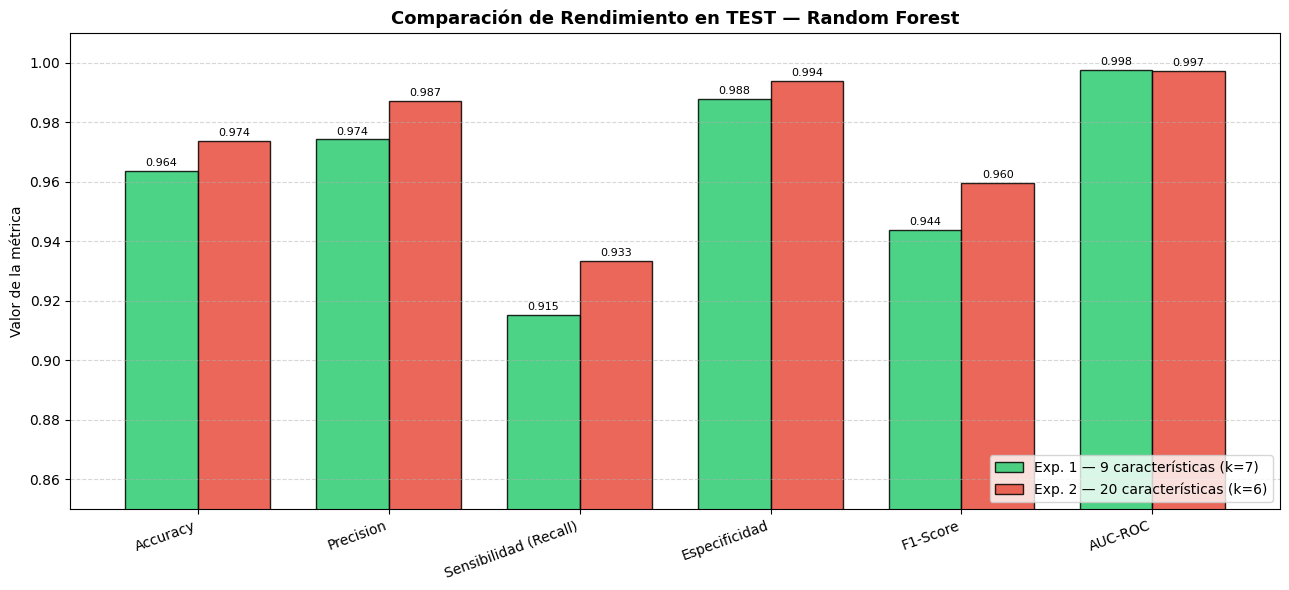

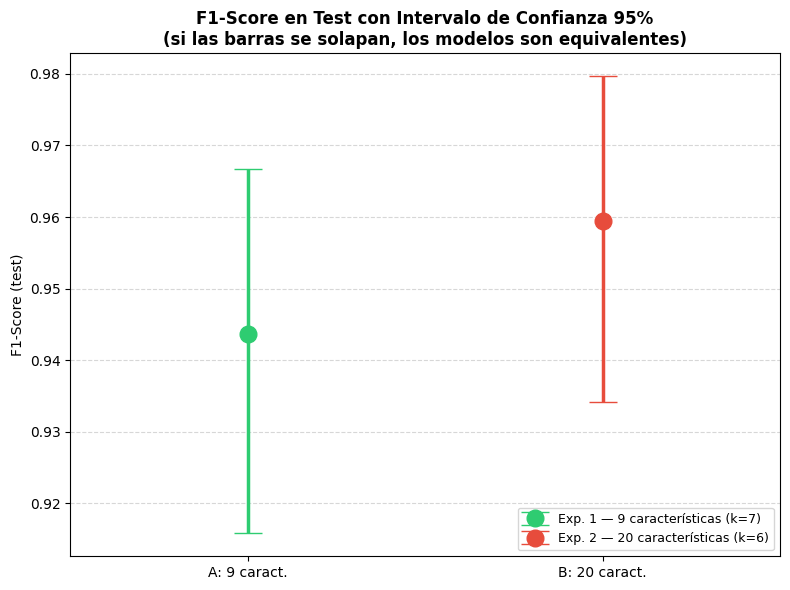


   CONCLUSIÓN
  F1 (A, 9 caract.):  0.9437  IC95% [0.9158 – 0.9667]
  F1 (B, 20 caract.): 0.9595  IC95% [0.9342 – 0.9797]

  >> Los intervalos de confianza del F1 SE SOLAPAN.
  >> Ambos enfoques son ESTADÍSTICAMENTE EQUIVALENTES en test.
  >> La diferencia observada no es significativa; conviene elegir el
     modelo por parsimonia (menos características = más simple).


In [ ]:
# =====================================================================
# CELDA 6 — COMPARACIÓN FINAL DE LOS DOS EXPERIMENTOS (TEST)
#           Compara Random Forest de ambos enfoques: métricas puntuales,
#           intervalos de confianza (bootstrap) y rendimiento global.
# =====================================================================
#
# REQUISITO: ejecutar antes las celdas de ambos experimentos.
# Esta celda lee las variables de test que cada experimento ya calculó.
# Para distinguirlas, ANTES de ejecutar esta celda, guarda los resultados
# de cada experimento con nombres únicos. Al FINAL de cada experimento
# (después de su bloque de bootstrap) añade UNA línea:
#
#   En el Experimento 1 (9 características):
#       resultados_exp1 = {'metricas': metrics_test_rf, 'ic': df_ic, 'nombre': 'Exp. 1 — 9 características (k=7)'}
#
#   En el Experimento 2 (20 características):
#       resultados_exp2 = {'metricas': metrics_test_rf, 'ic': df_ic, 'nombre': 'Exp. 2 — 20 características (k=6)'}
#
# (metrics_test_rf y df_ic ya existen en cada experimento; solo se
#  empaquetan con un nombre distinto para no sobrescribirse entre sí.)
# =====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Verificación de que ambos experimentos se ejecutaron
faltantes = [v for v in ['resultados_exp1', 'resultados_exp2'] if v not in dir()]
if faltantes:
    raise NameError(
        f"Faltan resultados: {faltantes}. Ejecuta ambos experimentos y añade al "
        f"final de cada uno la línea 'resultados_expN = {{...}}' indicada en el encabezado."
    )

exp1 = resultados_exp1
exp2 = resultados_exp2

print("=" * 70)
print("   COMPARACIÓN FINAL DE EXPERIMENTOS (CONJUNTO DE TEST)")
print("=" * 70)
print(f"   A: {exp1['nombre']}")
print(f"   B: {exp2['nombre']}")
print("=" * 70)

# ---------------------------------------------------------------------
# 1. TABLA COMPARATIVA DE MÉTRICAS PUNTUALES (TEST)
# ---------------------------------------------------------------------
metricas_orden = ['Accuracy', 'Precision', 'Sensibilidad (Recall)',
                  'Especificidad', 'F1-Score', 'AUC-ROC',
                  'Falsos Negativos', 'Falsos Positivos']

filas = []
for m in metricas_orden:
    v1 = exp1['metricas'].get(m, np.nan)
    v2 = exp2['metricas'].get(m, np.nan)
    # Para FN/FP gana el menor; para el resto gana el mayor
    if m in ('Falsos Negativos', 'Falsos Positivos'):
        mejor = 'A' if v1 < v2 else ('B' if v2 < v1 else '=')
    else:
        mejor = 'A' if v1 > v2 else ('B' if v2 > v1 else '=')
    filas.append({
        'Métrica': m,
        'A (9 caract.)': round(v1, 4) if isinstance(v1, float) else v1,
        'B (20 caract.)': round(v2, 4) if isinstance(v2, float) else v2,
        'Mejor': mejor
    })

df_comp = pd.DataFrame(filas)
print("\n--- TABLA COMPARATIVA DE MÉTRICAS PUNTUALES (TEST) ---")
display(df_comp)

# ---------------------------------------------------------------------
# 2. COMPARACIÓN DE INTERVALOS DE CONFIANZA (BOOTSTRAP)
# ---------------------------------------------------------------------
# Une los IC de ambos experimentos en una sola tabla y evalúa solapamiento.
ic1 = exp1['ic'].set_index('Métrica')
ic2 = exp2['ic'].set_index('Métrica')

filas_ic = []
for m in ic1.index:
    low1, high1 = ic1.loc[m, 'IC 95% inferior'], ic1.loc[m, 'IC 95% superior']
    low2, high2 = ic2.loc[m, 'IC 95% inferior'], ic2.loc[m, 'IC 95% superior']
    # ¿Se solapan los dos intervalos?
    solapan = (low1 <= high2) and (low2 <= high1)
    filas_ic.append({
        'Métrica': m,
        'A: valor': round(ic1.loc[m, 'Valor (test)'], 4),
        'A: IC 95%': f"[{low1:.4f} – {high1:.4f}]",
        'B: valor': round(ic2.loc[m, 'Valor (test)'], 4),
        'B: IC 95%': f"[{low2:.4f} – {high2:.4f}]",
        '¿Se solapan?': 'Sí' if solapan else 'NO'
    })

df_comp_ic = pd.DataFrame(filas_ic)
print("\n--- COMPARACIÓN DE INTERVALOS DE CONFIANZA (TEST, IC 95%) ---")
display(df_comp_ic)

# ---------------------------------------------------------------------
# 3. VISUALIZACIÓN: métricas puntuales lado a lado (barras)
# ---------------------------------------------------------------------
metricas_plot = ['Accuracy', 'Precision', 'Sensibilidad (Recall)',
                 'Especificidad', 'F1-Score', 'AUC-ROC']
vals1 = [exp1['metricas'][m] for m in metricas_plot]
vals2 = [exp2['metricas'][m] for m in metricas_plot]

x = np.arange(len(metricas_plot))
ancho = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - ancho/2, vals1, ancho, label=exp1['nombre'], color='#2ecc71', edgecolor='black', alpha=0.85)
b2 = ax.bar(x + ancho/2, vals2, ancho, label=exp2['nombre'], color='#e74c3c', edgecolor='black', alpha=0.85)

ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de Rendimiento en TEST — Random Forest', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metricas_plot, rotation=20, ha='right')
ax.set_ylim(0.85, 1.01)
ax.legend(loc='lower right')
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

# Etiquetas de valor sobre cada barra
for barras in (b1, b2):
    for b in barras:
        ax.annotate(f'{b.get_height():.3f}',
                    (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 2),
                    textcoords='offset points')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 4. VISUALIZACIÓN: F1-Score con barras de error (IC 95%)
#    Muestra visualmente si los intervalos de confianza se solapan.
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

for i, (exp, color) in enumerate([(exp1, '#2ecc71'), (exp2, '#e74c3c')]):
    ic = exp['ic'].set_index('Métrica')
    f1_val  = ic.loc['F1-Score', 'Valor (test)']
    f1_low  = ic.loc['F1-Score', 'IC 95% inferior']
    f1_high = ic.loc['F1-Score', 'IC 95% superior']
    # Barra de error asimétrica respecto al valor puntual
    err_low  = f1_val - f1_low
    err_high = f1_high - f1_val
    ax.errorbar(i, f1_val, yerr=[[err_low], [err_high]], fmt='o', color=color,
                capsize=10, markersize=12, linewidth=2.5, label=exp['nombre'])

ax.set_xticks([0, 1])
ax.set_xticklabels(['A: 9 caract.', 'B: 20 caract.'])
ax.set_ylabel('F1-Score (test)')
ax.set_title('F1-Score en Test con Intervalo de Confianza 95%\n(si las barras se solapan, los modelos son equivalentes)',
             fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, 1.5)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# 5. CONCLUSIÓN AUTOMÁTICA (basada en solapamiento del IC de F1)
# ---------------------------------------------------------------------
ic1f = exp1['ic'].set_index('Métrica').loc['F1-Score']
ic2f = exp2['ic'].set_index('Métrica').loc['F1-Score']
solapan_f1 = (ic1f['IC 95% inferior'] <= ic2f['IC 95% superior']) and \
             (ic2f['IC 95% inferior'] <= ic1f['IC 95% superior'])

print("\n" + "="*70)
print("   CONCLUSIÓN")
print("="*70)
print(f"  F1 (A, 9 caract.):  {ic1f['Valor (test)']:.4f}  IC95% [{ic1f['IC 95% inferior']:.4f} – {ic1f['IC 95% superior']:.4f}]")
print(f"  F1 (B, 20 caract.): {ic2f['Valor (test)']:.4f}  IC95% [{ic2f['IC 95% inferior']:.4f} – {ic2f['IC 95% superior']:.4f}]")
if solapan_f1:
    print("\n  >> Los intervalos de confianza del F1 SE SOLAPAN.")
    print("  >> Ambos enfoques son ESTADÍSTICAMENTE EQUIVALENTES en test.")
    print("  >> La diferencia observada no es significativa; conviene elegir el")
    print("     modelo por parsimonia (menos características = más simple).")
else:
    print("\n  >> Los intervalos de confianza del F1 NO se solapan.")
    print("  >> Existe una diferencia estadísticamente apreciable entre los enfoques.")

In [ ]:
print(caracteristicas_v2)

['Line_Length', 'Hurst', 'P_Theta', 'P_Beta', 'P_Gamma', 'PeakFreq_Alfa']


In [ ]:
import mne
import numpy as np
import joblib
from scipy.signal import resample, welch
from scipy.stats import skew, kurtosis, entropy

# =========================
# MODELOS
# =========================
model = joblib.load("modelo_rf_optimizado_eeg_v2.pkl")
scaler = joblib.load("escalador_robusto_v2.pkl")
selector = joblib.load("selector_caracteristicas_v2.pkl")

# =========================
# CONFIG
# =========================
FS_TARGET = 173.61
WINDOW_SIZE = int(2.0 * FS_TARGET)

bands = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alfa":  (8, 13),
    "Beta":  (13, 30),
    "Gamma": (30, 40)
}

# =========================
# FILTRO
# =========================
def butter_bandpass_filter(x, low, high, fs):
    from scipy.signal import butter, filtfilt
    b, a = butter(4, [low/(0.5*fs), high/(0.5*fs)], btype='band')
    return filtfilt(b, a, x)

# =========================
# FEATURES (17 EXACTAS)
# =========================
def sample_entropy(sig, m=2, r_factor=0.2):
    r = r_factor * np.std(sig)
    N = len(sig)

    def phi(m_val):
        templates = np.array([sig[i:i+m_val] for i in range(N - m_val)])
        count = 0
        for i in range(len(templates)):
            d = np.max(np.abs(templates - templates[i]), axis=1)
            count += np.sum(d <= r) - 1
        return count / (N - m_val)

    phi_m = phi(m)
    phi_m1 = phi(m+1)

    if phi_m == 0 or phi_m1 == 0:
        return 0.0

    return -np.log(phi_m1 / phi_m)


def hurst(sig):
    N = len(sig)
    if N < 20:
        return 0.5

    max_lag = int(np.log2(N))
    lags, rs = [], []

    for i in range(3, max_lag):
        lag = 2 ** i
        chunks = [sig[j*lag:(j+1)*lag] for j in range(N // lag)]

        vals = []
        for c in chunks:
            m = np.mean(c)
            y = np.cumsum(c - m)
            R = np.max(y) - np.min(y)
            S = np.std(c)
            if S > 0:
                vals.append(R / S)

        if vals:
            lags.append(np.log(lag))
            rs.append(np.log(np.mean(vals)))

    if len(lags) < 2:
        return 0.5

    H, _ = np.polyfit(lags, rs, 1)
    return H


def extract_features(sig, fs):

    sig = butter_bandpass_filter(sig, 0.5, 40, fs)

    skw = skew(sig)
    kurt = kurtosis(sig)
    line_length = np.sum(np.abs(np.diff(sig)))

    samp_ent = sample_entropy(sig)
    hurst_val = hurst(sig)

    freqs, psd = welch(sig, fs=fs, nperseg=256)

    band = {}
    peak = {}

    for k, (f1, f2) in bands.items():
        idx = (freqs >= f1) & (freqs <= f2)
        band[k] = np.sum(psd[idx]) if np.any(idx) else 0.0
        peak[k] = freqs[idx][np.argmax(psd[idx])] if np.any(idx) else 0.0

    eps = 1e-12

    spectral_entropy = entropy(psd / (np.sum(psd) + eps))

    ratio_theta_alfa = band["Theta"] / (band["Alfa"] + eps)
    ratio_slow_fast = (band["Delta"] + band["Theta"]) / (band["Beta"] + band["Gamma"] + eps)

    return [
        skw,
        kurt,
        line_length,

        samp_ent,
        hurst_val,

        band["Delta"],
        band["Theta"],
        band["Beta"],
        band["Gamma"],

        spectral_entropy,

        peak["Delta"],
        peak["Theta"],
        peak["Alfa"],
        peak["Beta"],
        peak["Gamma"],

        ratio_theta_alfa,
        ratio_slow_fast
    ]

# =========================
# LOAD EEG
# =========================
EDF_FILE = r"C:\Users\DELL\Documents\PN00-1.edf"

raw = mne.io.read_raw_edf(EDF_FILE, preload=True, verbose=False)

fs_real = raw.info['sfreq']
signal = raw.get_data(picks=["EEG T3"])[0]

# resample SOLO si es necesario
signal = resample(signal, int(len(signal) * FS_TARGET / fs_real))

# =========================
# ANOTACIONES ICTAL
# =========================
ICTAL_START_SEC = 1143
ICTAL_END_SEC = 1213

ictal_start = int(ICTAL_START_SEC * FS_TARGET)
ictal_end = int(ICTAL_END_SEC * FS_TARGET)

ictal_signal = signal[ictal_start:ictal_end]

# interictal lejos de crisis
interictal_signal = signal[int(200*FS_TARGET):int(400*FS_TARGET)]

# =========================
# VENTANAS (5 + 5)
# =========================
def make_windows(sig, n=5):
    max_w = len(sig) // WINDOW_SIZE
    n = min(n, max_w)

    return np.array([
        sig[i*WINDOW_SIZE:(i+1)*WINDOW_SIZE]
        for i in range(n)
    ])

X_ictal = make_windows(ictal_signal, 5)
X_inter = make_windows(interictal_signal, 5)

X = np.concatenate([X_ictal, X_inter], axis=0)

# =========================
# FEATURES
# =========================
X_feat = np.array([extract_features(w, FS_TARGET) for w in X])

print("Features shape:", X_feat.shape)

# =========================
# PIPELINE
# =========================
X_scaled = scaler.transform(X_feat)
X_final = selector.transform(X_scaled)

print("Final shape:", X_final.shape)

# =========================
# PREDICCIÓN
# =========================
proba = model.predict_proba(X_final)[:, 1]
pred = model.predict(X_final)

for i in range(len(pred)):
    tipo = "ICTAL" if i < 5 else "INTERICTAL"
    print(f"Ventana {i+1} ({tipo}): {pred[i]} | {proba[i]:.4f}")

Features shape: (10, 17)
Final shape: (10, 6)
Ventana 1 (ICTAL): 0 | 0.0000
Ventana 2 (ICTAL): 0 | 0.0000
Ventana 3 (ICTAL): 0 | 0.0000
Ventana 4 (ICTAL): 0 | 0.0000
Ventana 5 (ICTAL): 0 | 0.0000
Ventana 6 (INTERICTAL): 0 | 0.0000
Ventana 7 (INTERICTAL): 0 | 0.0000
Ventana 8 (INTERICTAL): 0 | 0.0000
Ventana 9 (INTERICTAL): 0 | 0.0000
Ventana 10 (INTERICTAL): 0 | 0.0000


In [ ]:
print("X_feat mean ICTAL:", np.mean(X_feat[:5], axis=0))
print("X_feat mean INTER:", np.mean(X_feat[5:], axis=0))

X_feat mean ICTAL: [-6.34390688e-01  1.56589822e+00  2.82726383e-03  1.07347451e+00
  8.68078201e-01  3.99405552e-10  3.10146458e-11  1.42412960e-10
  1.74890384e-10  3.22725570e+00  1.49196094e+00  5.15404688e+00
  1.11218906e+01  1.84460625e+01  3.45863672e+01  1.31635173e+00
  2.14877968e+00]
X_feat mean INTER: [-1.67310973e+00  4.21274292e+00  5.56548050e-04  4.61090623e-01
  9.53249275e-01  2.73105398e-10  3.54025926e-11  5.90348651e-12
  5.69256370e-13  2.05363629e+00  1.22069531e+00  5.42531250e+00
  8.81613281e+00  1.66828359e+01  3.21449766e+01  5.53767326e+00
  4.20931809e+01]


In [ ]:
print("Scaler means:", scaler.center_[:10])
print("Scaler scale:", scaler.scale_[:10])
print("Selector support:", selector.get_support())

Scaler means: [-8.05338600e-02 -4.66461378e-02  3.77198457e+03  5.33461468e-01
  8.72796753e-01  2.92544998e+03  1.22248252e+03  2.38011147e+02
  7.69926350e+00  2.44507991e+00]
Scaler scale: [7.09247159e-01 1.07662302e+00 9.89922427e+03 1.66676779e-01
 1.26957232e-01 1.00272334e+04 1.52886894e+04 3.72153756e+03
 6.77554947e+01 5.05769002e-01]
Selector support: [False False  True False  True False  True  True  True False False False
  True False False False False]
